# ASTRAL Visualizations

Here I am trying to understand some of the results from various ASTRAL papers

In [14]:
import matplotlib.pyplot as plt
from math import factorial, exp
import warnings
import numpy as np
from math import log
import seaborn as sns

sns.set_theme()

warnings.filterwarnings('ignore')

# Set up matplotlib for better display in Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

### Bipartition Covers

Here I was reading the paper [An analytical upper bound on the number of loci required for all splits of a species tree to appear in a set of gene trees](https://pmc.ncbi.nlm.nih.gov/articles/PMC5123308/pdf/12859_2016_Article_1266.pdf) which gives a bound on the number of genes required so the gene trees form a bipartition cover of the sepcies tree with high probability. It involves this coalescent function $g_{ij}(T)$ which I am trying to understand its behavior. It gives the probability that $i$ lineages coalesce to $j$ lineages in time $T$ (in coalescent units) under Kingman's coalescence.

Just based on its definition it ought to satisfy some properties. For example, to go from $i$ lineages to $j$ lineages we know for any $k$ so $j < k < i$ it must have $k$ lineages at some point in between. Namely, conditioning on the time this occurs at we see there's this analog of Kolmogorov's equations:

$$g_{ij}(T) = \int_0^T g_{ik}(t)g_{kj}(T-t) \; dt$$

In [15]:
def falling_factorial(i, k):
    if k < 0:
        raise ValueError(f'Negative k = {k} passed')
    if k == 0:
        return 1
    
    return falling_factorial(i-1, k-1) * i
    
def rising_factorial(i, k):
    if k < 0:
        raise ValueError(f'Negative k = {k} passed')
    if k == 0:
        return 1
    
    return rising_factorial(i+1, k-1) * i

In [16]:
def g_ij(T, i, j):
    """
    Calculate g_ij(T) according to equation (1) with factorial corrections:
    
     g_{ij}(T) := \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}j_{(k-1)} i_{[k]}}{j!(k-j)!i_{(k)}}
    """
    if i < j:
        return 0.0
    
    total_sum = 0.0
    j_factorial = factorial(j)  # This should be standard factorial
    
    try:
        for k in range(j, i + 1):
            # Calculate each term in the sum
            exponential_term = exp(-k * (k - 1) * T / 2)
            coefficient = (2 * k - 1)
            sign_term = (-1) ** (k - j)
            
            # Factorial terms
            j_rising_k_minus_1 = rising_factorial(j, k-1)     # j_{(k-1)}
            i_falling_k = falling_factorial(i, k)             # i_{[k]}
            i_rising_k = rising_factorial(i, k)               # i_{(k)}
            
            # Denominator
            k_minus_j_factorial = factorial(k - j)
            denominator = j_factorial * k_minus_j_factorial * i_rising_k
            
            # Complete term
            if denominator != 0:
                numerator = (exponential_term * coefficient * sign_term * 
                           j_rising_k_minus_1 * i_falling_k)
                term = numerator / denominator
                total_sum += term
                
    except OverflowError:
        print(f"Warning: Overflow occurred for large factorials at i={i}, j={j}")
        return np.inf
    
    return total_sum


def plot_g_ij_vs_i(T, j, i_range=None, max_i=20, log_plot=False):
    """
    Plot g_ij(T) as a function of i for fixed T and j
    """
    if i_range is None:
        i_range = range(j, max_i + 1)  # i must be >= j for the sum to be valid
    
    i_values = list(i_range)
    g_values = [g_ij(T, i, j) for i in i_values]
    
    plt.figure(figsize=(10, 6))
    if log_plot:
        plt.semilogy(i_values, g_values, 'bo-', linewidth=2, markersize=6)
    else:
        plt.plot(i_values, g_values, 'bo-', linewidth=2, markersize=6)
        
    plt.xlabel('i', fontsize=12)
    plt.ylabel(f'$g_{{ij}}(T)$', fontsize=12)
    plt.title(f'$g_{{ij}}(T)$ vs i for T={T}, j={j}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return i_values, g_values

Now that we have defined our function $g_{ij}(T)$ we can try to numerically explore some of its properties. In particular, we observe that:

* Note that $g_{i,1}(T)$ is decreasing in $i$ as we just need more things to coalesce, although interestingly it does NOT appear that in general $g_{i,j}(T)$ is decreasing in $i$. For $j= 2$ it seems to initially increase, level off, and then decrease down to some limit. For $j > 2$ it almost just looks increasing. It would be cool to understand this more. 
* For fixed $T$ the function $g_{i,1}(T)$ appears to be convex in $i$. This sort of makes sense. Clearly it has to be decreasing as its harder for everything to coalesce if there are more things that have to coalesce. Moreover, its a probability so its bounded below by zero (and above by one). 

Comparing different j values for T=1.0


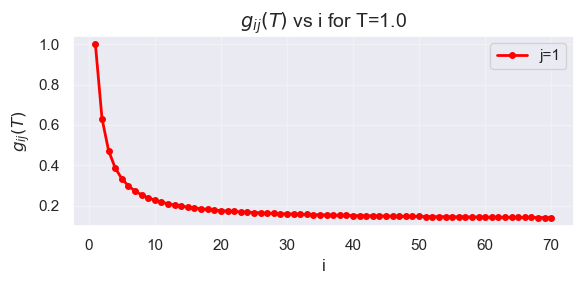

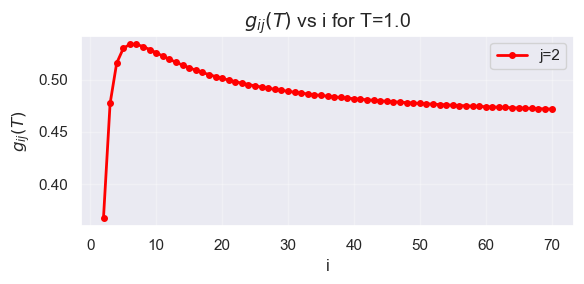

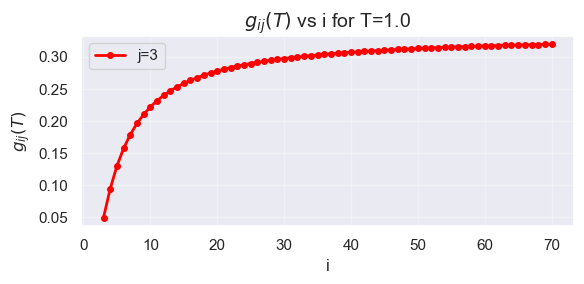

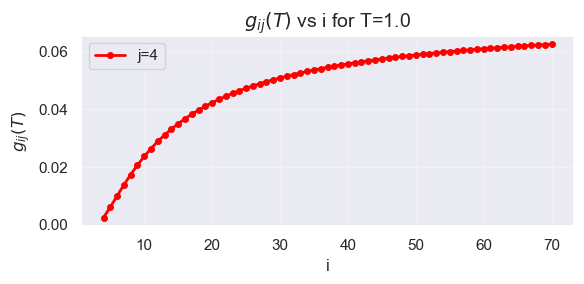

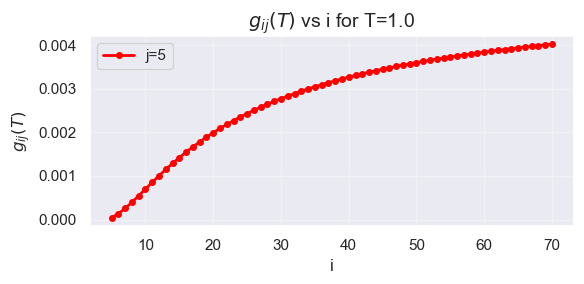

In [4]:
# Plot g_{ij}(T) as a function of i for various j
# Plot comparison for different j values
T = 1.0
j_values = list(range(1, 6))
max_i = 70
print(f"Comparing different j values for T={T}")

def plot_multiple_j_values(T, j_values, max_i=20):
    """
    Plot g_ij(T) for multiple j values on separate subplots
    """
    
    
    for j in j_values:
        plt.figure(figsize=(6, 3))
        i_range = range(j, max_i + 1)
        i_values = list(i_range)
        g_values = [g_ij(T, i, j) for i in i_values]
        plt.plot(i_values, g_values, 'o-', linewidth=2, markersize=4, color='red', label=f'j={j}')
        plt.xlabel('i', fontsize=12)
        plt.ylabel(f'$g_{{ij}}(T)$', fontsize=12)
        plt.title(f'$g_{{ij}}(T)$ vs i for T={T}', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_multiple_j_values(T, j_values, max_i=max_i)

Now we plot $f(i, j) = 1-\sum_{k \leq j} g_{ik}(T)$

Comparing different j values for T=1.0


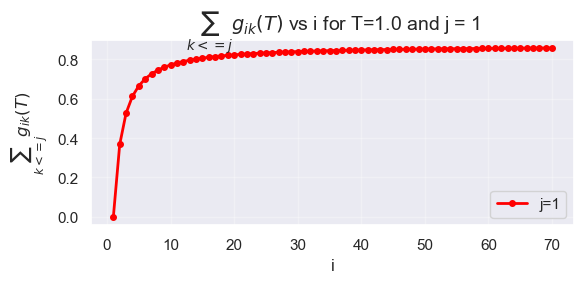

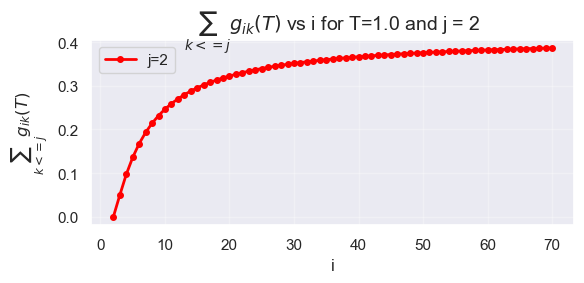

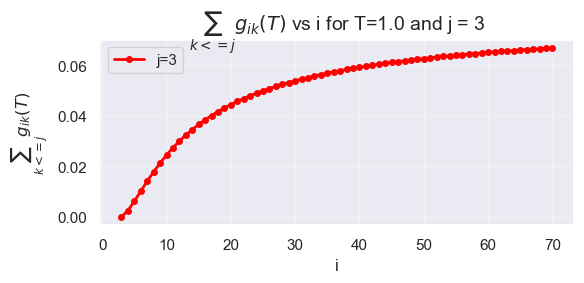

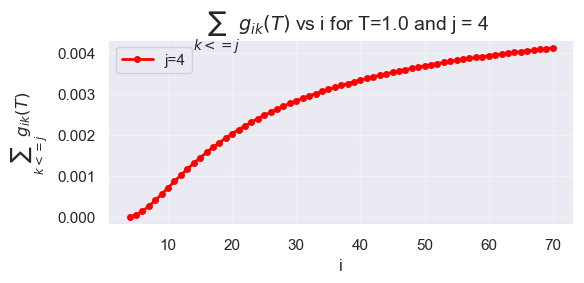

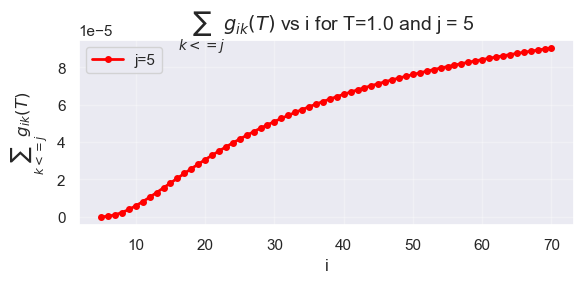

In [5]:
# Plot cummulative sum of g_ij
# Plot g_{ij}(T) as a function of i for various j
# Plot comparison for different j values
T = 1.0
j_values = list(range(1, 6))
max_i = 70
print(f"Comparing different j values for T={T}")

def plot_sum_j_values(T, j_values, max_i=20):
    """
    Plot g_ij(T) for multiple j values on separate subplots
    """
    
    
    for j in j_values:
        plt.figure(figsize=(6, 3))
        i_range = range(j, max_i + 1)
        i_values = list(i_range)
        g_values = [1-sum([g_ij(T, i, k) for k in range(1,j+1)]) for i in i_values]
        plt.plot(i_values, g_values, 'o-', linewidth=2, markersize=4, color='red', label=f'j={j}')
        plt.xlabel('i', fontsize=12)
        plt.ylabel(f'$\sum_{{k <= j}} g_{{ik}}(T)$', fontsize=12)
        plt.title(f'$\sum_{{k <= j}} g_{{ik}}(T)$ vs i for T={T} and j = {j}', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_sum_j_values(T, j_values, max_i=max_i)

Comparing different T values for j=1


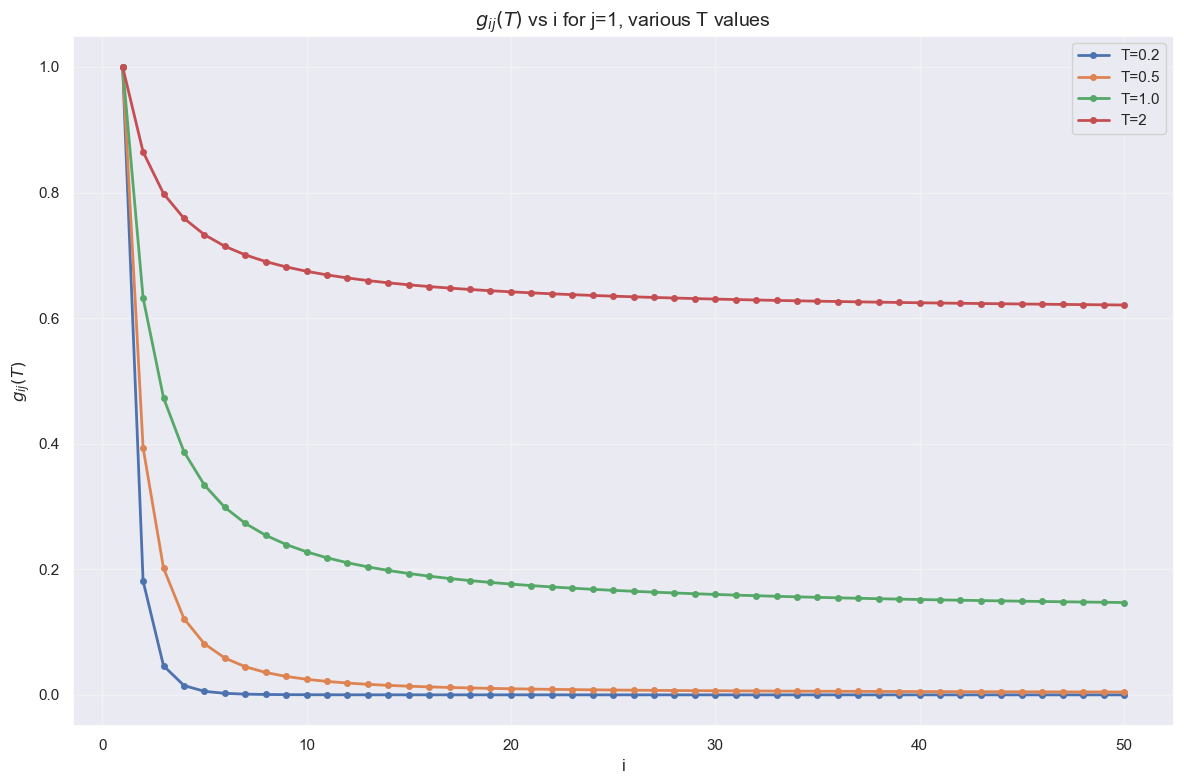

In [6]:
# Cell 6: Compare different T values
def plot_multiple_T_values(j, T_values, max_i=20):
    """
    Plot g_ij(T) for multiple T values on the same graph
    """
    plt.figure(figsize=(12, 8))
    
    for T_val in T_values:
        i_range = range(j, max_i + 1)
        i_values = list(i_range)
        g_values = [g_ij(T_val, i, j) for i in i_values]
        plt.plot(i_values, g_values, 'o-', linewidth=2, markersize=4, label=f'T={T_val}')
    
    plt.xlabel('i', fontsize=12)
    plt.ylabel(f'$g_{{ij}}(T)$', fontsize=12)
    plt.title(f'$g_{{ij}}(T)$ vs i for j={j}, various T values', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot comparison for different T values
j = 1
T_values = [0.2, 0.5, 1.0, 2]
print(f"Comparing different T values for j={j}")
plot_multiple_T_values(j, T_values, max_i=50)

Again what we are really curious about is trying to bound the sum:

$$\sum_{e \in E^\circ(T)} [1-g_{k_e1}(T_{min})^n]$$

as referenced in the paper. We are particularly interested in minimizing the given sum. To do so, we want to try to find the worst-case tree, the one minimizing this guy. We have a sense it ought to be one of the "extremal" trees: either the catepillar tree or the balanced tree.

In [7]:
def max_path_helper(n,f, memos):
    
    max_val = 0
    for i in range(1, n):

        # Check saved DP values
        if i not in memos:
            memos[i] = f(i)
        if n-i not in memos:
            memos[n-i] = f(n-i)
            
        # Recurrse
        next_val = memos[i] + memos[n-i] + max_path_helper(i, f, memos) + max_path_helper(n-i, f, memos)
        
        # Update max value
        max_val = max(next_val, max_val)
        
    return max_val
        
        
def max_path(n,f):
    '''
        Given a function f:N->R we find the maximum value sum_e f(descendants(e)) can take on over all possible
        rooted binary tree topologies, where descendants(e) is the number of leaves below the given edge in the tree.
    '''
    memos = dict()
    return max_path_helper(n, f, memos) 

In [8]:
T = 1
j = 1
max_i = 10
f = lambda i: g_ij(T,i,j)

max_path(max_i, f)

14.233355927253568

I have adjusted the code now to do the standard backtracking and plot the corresponding optimal path as a tree. This just makes it a bit easier to see what is going on. It's still a little buggy. 

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import numpy as np

class TreeNode:
    def __init__(self, value, left_split=None, right_split=None):
        self.value = value  # The n value for this subproblem
        self.left_split = left_split  # Size of left split (i)
        self.right_split = right_split  # Size of right split (n-i)
        self.left_child = None
        self.right_child = None
        self.x = 0  # Position for plotting
        self.y = 0

def max_path_helper_with_tree(n, f, memos, splits):
    if n == 1:
        # Create a leaf node for base case - this is crucial for showing leaf edges!
        leaf_node = TreeNode(1)
        memos[1] = 0
        splits[1] = leaf_node
        return 0, leaf_node
    
    if n in memos:
        return memos[n], splits.get(n, None)
    
    max_val = -np.inf
    best_split = None
    
    for i in range(1, n):
        # Check saved DP values for f
        if i not in memos:
            left_val, left_tree = max_path_helper_with_tree(i, f, memos, splits)
            memos[i] = left_val
            if left_tree:
                splits[i] = left_tree
                
        if n-i not in memos:
            right_val, right_tree = max_path_helper_with_tree(n-i, f, memos, splits)
            memos[n-i] = right_val
            if right_tree:
                splits[n-i] = right_tree
        
        # Calculate total value for this split
        next_val = f(i) + f(n-i) + memos[i] + memos[n-i]
        
        # Update max value and best split
        if next_val > max_val:
            max_val = next_val
            best_split = (i, n-i)
    
    # Create tree node for this optimal split
    if best_split:
        tree_node = TreeNode(n, best_split[0], best_split[1])
        tree_node.left_child = splits.get(best_split[0], None)
        tree_node.right_child = splits.get(best_split[1], None)
        memos[n] = max_val
        return max_val, tree_node
    
    return max_val, None

def max_path_with_tree(n, f):
    memos = dict()  # Stores optimal values for DP efficiency
    splits = dict()  # Stores optimal split choices (i, n-i) tuples
    max_val, tree = max_path_helper_with_tree(n, f, memos, splits)
    return max_val, tree

def assign_positions(node, x=0, y=0, x_spacing=1.0, y_spacing=1.0, level_width=None):
    """Assign x, y positions to nodes for plotting"""
    if node is None:
        return
    
    if level_width is None:
        level_width = defaultdict(int)
        count_nodes_per_level(node, 0, level_width)
    
    node.x = x
    node.y = y
    
    if node.left_child or node.right_child:
        # Calculate spacing for children
        child_spacing = x_spacing * 0.7  # Reduce spacing as we go down
        left_x = x - child_spacing
        right_x = x + child_spacing
        child_y = y - y_spacing
        
        if node.left_child:
            assign_positions(node.left_child, left_x, child_y, child_spacing, y_spacing, level_width)
        if node.right_child:
            assign_positions(node.right_child, right_x, child_y, child_spacing, y_spacing, level_width)

def count_nodes_per_level(node, level, level_width):
    """Count nodes at each level to help with spacing"""
    if node is None:
        return
    
    level_width[level] += 1
    
    if node.left_child:
        count_nodes_per_level(node.left_child, level + 1, level_width)
    if node.right_child:
        count_nodes_per_level(node.right_child, level + 1, level_width)

def plot_tree(tree, f=None, figsize=(12, 8)):
    """Plot the splitting tree with edge labels"""
    if tree is None:
        print("No tree to plot")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Assign positions to nodes
    assign_positions(tree, x=0, y=0, x_spacing=3.0, y_spacing=1.5)
    
    # Draw tree
    draw_tree_recursive(ax, tree, f)
    
    # Set axis properties
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Get bounds and add padding
    all_x, all_y = get_all_positions(tree)
    if all_x and all_y:
        padding = 1.0
        ax.set_xlim(min(all_x) - padding, max(all_x) + padding)
        ax.set_ylim(min(all_y) - padding, max(all_y) + padding)
    
    plt.title("Optimal Splitting Tree")
    plt.tight_layout()
    plt.show()

def get_all_positions(node):
    """Get all x, y positions from the tree"""
    if node is None:
        return [], []
    
    x_coords = [node.x]
    y_coords = [node.y]
    
    if node.left_child:
        left_x, left_y = get_all_positions(node.left_child)
        x_coords.extend(left_x)
        y_coords.extend(left_y)
    
    if node.right_child:
        right_x, right_y = get_all_positions(node.right_child)
        x_coords.extend(right_x)
        y_coords.extend(right_y)
    
    return x_coords, y_coords

def draw_tree_recursive(ax, node, f=None):
    """Recursively draw the tree"""
    if node is None:
        return
    
    # Draw the current node
    circle = plt.Circle((node.x, node.y), 0.3, color='lightblue', ec='black')
    ax.add_patch(circle)
    
    # Add node label (the value n)
    ax.text(node.x, node.y, str(node.value), ha='center', va='center', 
            fontweight='bold', fontsize=10)
    
    # If we have f function, show f(n) below the node
    if f is not None:
        ax.text(node.x, node.y - 0.6, f'f({node.value})={f(node.value)}', 
                ha='center', va='center', fontsize=8, style='italic')
    
    # Draw edges to children with labels
    if node.left_child:
        # Draw line to left child
        ax.plot([node.x, node.left_child.x], [node.y, node.left_child.y], 
                'k-', linewidth=2)
        
        # Add edge label (the split size)
        mid_x = (node.x + node.left_child.x) / 2 - 0.2
        mid_y = (node.y + node.left_child.y) / 2
        ax.text(mid_x, mid_y, str(node.left_split), ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7),
                fontweight='bold')
        
        # Recurse on left child
        draw_tree_recursive(ax, node.left_child, f)
    
    if node.right_child:
        # Draw line to right child
        ax.plot([node.x, node.right_child.x], [node.y, node.right_child.y], 
                'k-', linewidth=2)
        
        # Add edge label (the split size)
        mid_x = (node.x + node.right_child.x) / 2 + 0.2
        mid_y = (node.y + node.right_child.y) / 2
        ax.text(mid_x, mid_y, str(node.right_split), ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7),
                fontweight='bold')
        
        # Recurse on right child
        draw_tree_recursive(ax, node.right_child, f)

def verify_tree_property(node):
    """Verify that each node's value equals the sum of its children's edge labels"""
    if node is None:
        return True
    
    # Leaf nodes (value 1) should have no children
    if node.value == 1:
        return node.left_child is None and node.right_child is None
    
    # Internal nodes should have the sum property
    if node.left_split is not None and node.right_split is not None:
        if node.left_split + node.right_split != node.value:
            print(f"Property violation at node {node.value}: {node.left_split} + {node.right_split} ≠ {node.value}")
            return False
    
    # Recursively check children
    return (verify_tree_property(node.left_child) and 
            verify_tree_property(node.right_child))


--- Testing with n = 8 ---
Maximum value: -13.798616542560438
Tree property verification: True


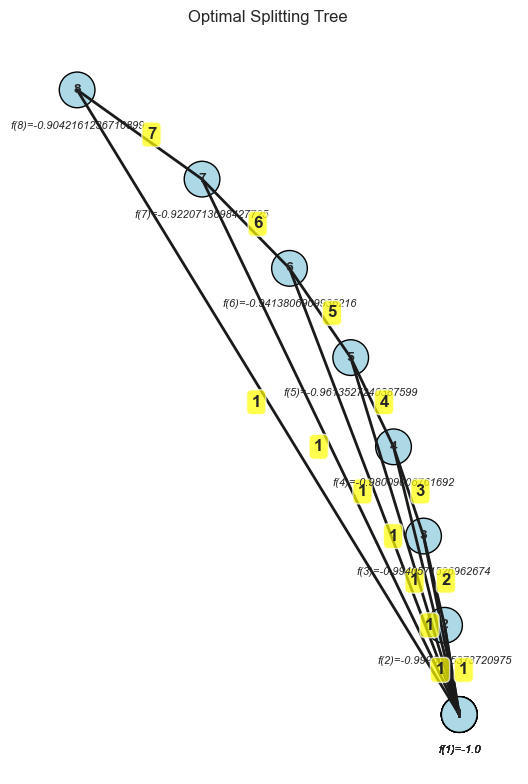

In [10]:
T = 1
j = 1
max_i = 10
n=4
f = lambda i: -(1- pow(1-g_ij(T,i,j), n))
#f = lambda x: x**2

# Test with different values
for n in [ 8]:
    print(f"\n--- Testing with n = {n} ---")
    max_val, tree = max_path_with_tree(n, f)
    print(f"Maximum value: {max_val}")

    if tree:
        print("Tree property verification:", verify_tree_property(tree))
        plot_tree(tree, f)
    else:
        print("No tree generated (n too small)")

#### Comparing the New and Old Bound

Suppose we have $k$ species and we would like to recover the bipartition cover with probability at least $q$. How many $n$ gene trees do we need to accomplish this? The original paper produced a bound of the form:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\log\left(1-g_{k-2,1}(T_{min}) \right)}$$

I think I may have been able to improve this bound to something along the lines:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\frac{1}{k-3}\sum_{\ell=2}^{k-2}\log\left(1-g_{\ell,1}(T_{min}) \right)}$$

Let's see if this is a significant improvement on the previous bound.
* It seems to drastically improve the bound when $T$ is small, which is sort of expected: we saw for small $T$ the function $\ell \mapsto g_{\ell 1}(T)$ drops off rapidly. Hence bounding $g_{k_i,1}(T)$ by $g_{k-2,1}(T)$ is very lossy in this regime. 
* For most values of $T_{min}$ the improvement is more modest, between 1.5-10, but still significant I feel. Esepcially because the paper mentions that there are on the order of $10^4-10^5$ independent genes in the genome, it is important to try to stay below this number. My bound is definitely much more able to do so

In [11]:
def original_bound(k, T_min, q=0.95):
    """
    Calculate the original bound:
    n >= log((1-q)/(k-3)) / log(1 - g_{k-2,1}(T_min))
    """
    if k <= 3:
        return float('inf')
    
    try:
        g_val = g_ij(T_min, k-2, 1)
        if g_val >= 1:  # Avoid log(0) or log(negative)
            return float('inf')
        
        numerator = log((1-q)/(k-3))
        denominator = log(1 - g_val)
        
        if denominator >= 0:  # log(1-g) should be negative
            return float('inf')
            
        return numerator / denominator
        
    except (ValueError, ZeroDivisionError):
        return float('inf')

def improved_bound(k, T_min, q=0.95):
    """
    Calculate the improved bound:
    n >= log((1-q)/(k-3)) / (1/(k-3) * sum_{l=2}^{k-2} log(1 - g_{l,1}(T_min)))
    """
    if k <= 3:
        return float('inf')
    
    try:
        # Calculate sum of log terms
        log_sum = 0
        for ell in range(2, k-1):  # l from 2 to k-2
            g_val = g_ij(T_min, ell, 1)
            if g_val >= 1:  # Avoid log(0) or log(negative)
                return float('inf')
            log_term = log(1 - g_val)
            if log_term >= 0:  # Should be negative
                return float('inf')
            log_sum += log_term
        
        if log_sum == 0:  # Avoid division by zero
            return float('inf')
            
        numerator = log((1-q)/(k-3))
        denominator = log_sum / (k-3)
        
        if denominator >= 0:  # Should be negative
            return float('inf')
            
        return numerator / denominator
        
    except (ValueError, ZeroDivisionError):
        return float('inf')

def plot_bounds_comparison(k_range, T_values, q=0.95, figsize=(12, 8)):
    """
    Plot comparison of original vs improved bounds
    """
    plt.figure(figsize=figsize)
    
    # Color palette for different T values
    colors = plt.cm.viridis(np.linspace(0, 1, len(T_values)))
    
    for i, T in enumerate(T_values):
        original_bounds = []
        improved_bounds = []
        valid_k = []
        
        for k in k_range:
            orig_bound = original_bound(k, T, q)
            impr_bound = improved_bound(k, T, q)
            
            # Only include finite, reasonable bounds
            if (orig_bound < float('inf') and impr_bound < float('inf') and 
                orig_bound > 0 and impr_bound > 0):
                original_bounds.append(np.log10(orig_bound))
                improved_bounds.append(np.log10(impr_bound))
                valid_k.append(k)
        
        if len(valid_k) > 0:
            # Plot original bound (dotted line)
            plt.plot(valid_k, original_bounds, '--', color=colors[i], 
                    linewidth=2, alpha=0.8)
            
            # Plot improved bound (solid line)
            plt.plot(valid_k, improved_bounds, '-', color=colors[i], 
                    linewidth=2, label=f'T={T}')
            
    plt.plot([], [], '-', color='black', label='New bound')
    plt.plot([], [], '--', color='black', label='Old bound')
    
    plt.xlabel('Number of Species (k)', fontsize=12)
    plt.ylabel('log10(n) - Log Number of Gene Trees', fontsize=12)
    plt.title(f'Comparison of Bounds for Gene Tree Recovery (q={q})', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_improvement_ratio(k_range, T_values, q=0.95, figsize=(10, 6), log_plot=True):
    """
    Plot improvement ratio as a function of T for different k values
    """
    plt.figure(figsize=figsize)
    
    # Select a subset of k values for cleaner visualization
    k_subset = k_range
    colors = plt.cm.plasma(np.linspace(0, 1, len(k_subset)))
    
    for i, k in enumerate(k_subset):
        improvement_ratios = []
        valid_T = []
        
        for T in T_values:
            orig_bound = original_bound(k, T, q)
            impr_bound = improved_bound(k, T, q)
            
            if (orig_bound < float('inf') and impr_bound < float('inf') and 
                orig_bound > 0 and impr_bound > 0):
                ratio = orig_bound / impr_bound
                improvement_ratios.append(ratio)
                valid_T.append(T)
        
        if len(valid_T) > 0:
            
            if log_plot:
                plt.semilogy(valid_T, improvement_ratios, 'o-', color=colors[i], 
                        linewidth=2, markersize=6, label=f'k = {k}')
            else:
                plt.plot(valid_T, improvement_ratios, 'o-', color=colors[i], 
                        linewidth=2, markersize=6, label=f'k = {k}')
    
    plt.xlabel('$T_{min}$ (Min Branch Length)', fontsize=12)
    plt.ylabel('Improvement Ratio (Original/Improved)', fontsize=12)
    plt.title('Improvement Ratio vs $T_{min}$ for Different Species Counts', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='No improvement')
    plt.legend()
    plt.tight_layout()
    plt.show()

def calculate_improvement_ratio(k_range, T_values, q=0.95):
    """
    Calculate and display the improvement ratio
    """
    print("Improvement Analysis:")
    print("=" * 50)
    
    for T in T_values:
        print(f"\nT_min = {T}:")
        improvements = []
        
        for k in k_range:
            orig_bound = original_bound(k, T, q)
            impr_bound = improved_bound(k, T, q)
            
            if (orig_bound < float('inf') and impr_bound < float('inf') and 
                orig_bound > 0 and impr_bound > 0):
                ratio = orig_bound / impr_bound
                improvements.append(ratio)
                if k % 5 == 0:  # Print every 5th value
                    print(f"  k={k}: Original/Improved = {ratio:.2f}x")
        
        if improvements:
            avg_improvement = np.mean(improvements)
            max_improvement = np.max(improvements)
            print(f"  Average improvement: {avg_improvement:.2f}x")
            print(f"  Maximum improvement: {max_improvement:.2f}x")



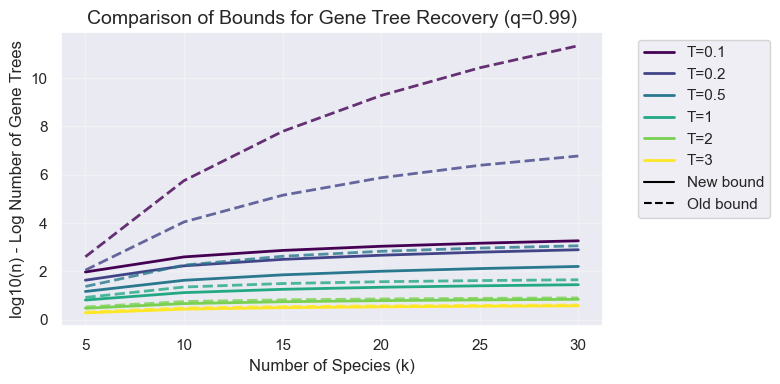

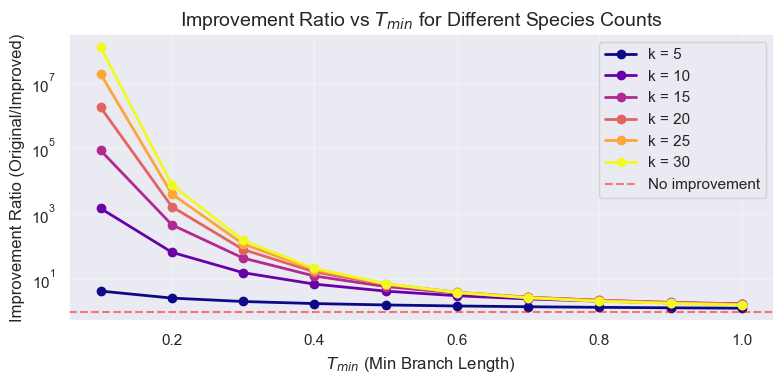

In [12]:
# Example usage - modify these parameters as needed
k_range = range(5, 35, 5)  # Species from 4 to 20

q = 0.99  # Probability threshold

# Create the comparison plot
T_values = [0.1, 0.2, 0.5, 1, 2, 3]
plot_bounds_comparison(k_range, T_values, q, figsize=(8,4))

# Plot improvement ratio
T_values = np.linspace(0.1, 1, 10)  
plot_improvement_ratio(k_range, T_values, q, log_plot=True, figsize=(8,4))

## Improvement 2: Extending the Coalescent Window

As we discussed above, for small values of $T_{min}$ the bound above is dominated by the terms $g_{k_i,1}$ for which $k_i$ are quite large. Heuristically, these are the edges close to the root of the tree which have many descendants. But our naive bound assumes \textit{none} of the descendants coalesce before they reach edge $e$, which is a bit pessimistic. Instead we could try to see what a typical number of descendants reach the given edge $e$ in some sense.

Namely, let $h_{i, j}(T_{min})$ denote the probability that $i$ lineages coalesce into exactly $j$ in a tree with $i$ leaves and minimum branch length $T_{min}$. Then clearly:

$$\mathbb{P}(E_{i,1}) \geq h_{k_i, 1}(T_{min}) \geq g_{k_i,1 }(T_{min})$$

so really we can try to bound $h$ instead. 

#### One-Step Improvement

Here is one simple improvement: we just consider a second coalescent period. Namely, instead of requiring all lineages coalesce in the single branch $e$ we require (i) all lineages in the left subtree below $e$ coalesce and (ii) all lineages in the right subtree below $e$ coalesce and (iii) these two lineages coalesce along $e$. This immediately gives the bound:


$$h_{i, 1}(T_{min}) \geq g_{2,1}(T_{min}) \cdot min_{1 \leq m < i}\left( g_{m,1}(T_{min})g_{i-m,1}(T_{min}) \right)$$

Hopefully by studying this worst-case we can extend it to a worse-case analysis for deeper trees. First, some simulations.


In [13]:
def plot_one_step_analysis(i, T_min):
    
    x_values = list(range(1, i))
    y_values = np.ones(i) * g_ij(T_min, 2,1)
    
    for m in range(1, i):
        y_values[m] *= g_ij(T_min, m, 1) * g_ij(T_min, i-m, 1)
        
    y_values = y_values[1:]
    plt.plot(x_values, y_values, label='New Lowerbound')
    plt.title("Title")
    plt.xlabel('m')
    plt.ylabel("Value of Lowerbound")
    
    # Plot old bound for comparison
    old_bound = g_ij(T_min, i, 1)
    plt.axhline(old_bound, color='red', ls='--', label='old_bound')
    
    plt.legend(loc='upper right')
    plt.show()

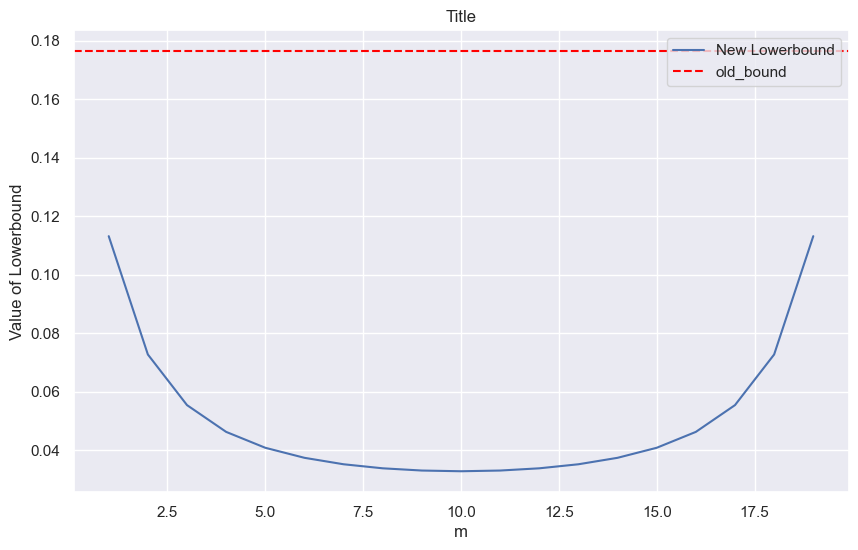

In [14]:
T = 1
i_val = 20
plot_one_step_analysis(i_val, T)

The above seems too naive on its own; the old bound is still tighter than what we propose. Here is a simple improvement: we just don't force the subtrees to both coalesce down to one. Instead, we allow them to coalesce down to whatever. we just consider a second coalescent period. Namely, instead of requiring all lineages coalesce in the single branch $e$ we require (i) lineages in the left subtree below $e$ coalesce from $m$ to $\ell$ (ii) all lineages in the right subtree below $e$ coalesce from $i-m$ to $r$ and (iii) these $r + \ell$ remaining lineages coalesce along $e$. This immediately gives the bound:


$$h_{i, 1}(T_{min}) \geq  min_{1 \leq m < i}\left(\sum_{r, \ell} g_{r+\ell,1}(T_{min}) \cdot g_{m,\ell}(T_{min})g_{i-m,r}(T_{min}) \right)$$

Hopefully by studying this worst-case we can extend it to a worse-case analysis for deeper trees. First, some simulations.


In [15]:
def plot_one_step_analysis_improved(i, T_min, make_plot=True):
    
    x_values = list(range(1, i))
    y_values = np.zeros(i)
    
    for m in range(1, i):
        for ell in range(1, m+1):
            for r in range(1, i-m + 1):
                y_values[m] += g_ij(T_min, r+ell, 1) * g_ij(T_min, m, ell) * g_ij(T_min, i-m, r)
        
    y_values = y_values[1:]
    new_bound = min(y_values)
    minimizing_m = np.argmin(y_values) + 1
    old_bound = g_ij(T_min, i, 1)
    improvement_ratio = new_bound / old_bound
    
    if make_plot:
        plt.plot(x_values, y_values)
        plt.title("Comparison of Old and New Bound")
        plt.xlabel('m')
        plt.ylabel("Value of Lowerbound")

        # Plot old bound for comparison
        plt.axhline(old_bound, color='red', ls='--', label='Old bound $g_{i1}(T_{min})$')
        plt.axhline(new_bound, color='orange', ls='--', label=f'New Bound (m = {minimizing_m})')
        plt.legend(loc='upper right')

        print("Minimizer m = ", minimizing_m)
        print(f'Improvement Ratio: {improvement_ratio}')
    
        plt.show()
    
    return improvement_ratio
    


Now we plot the quantity being minimized as a function of $m$ (the blue line below) and compare the new lowerbound it generates to the old bound $g_{i1}(T_{min})$.

Minimizer m =  20
Improvement Ratio: 154.36980775745354


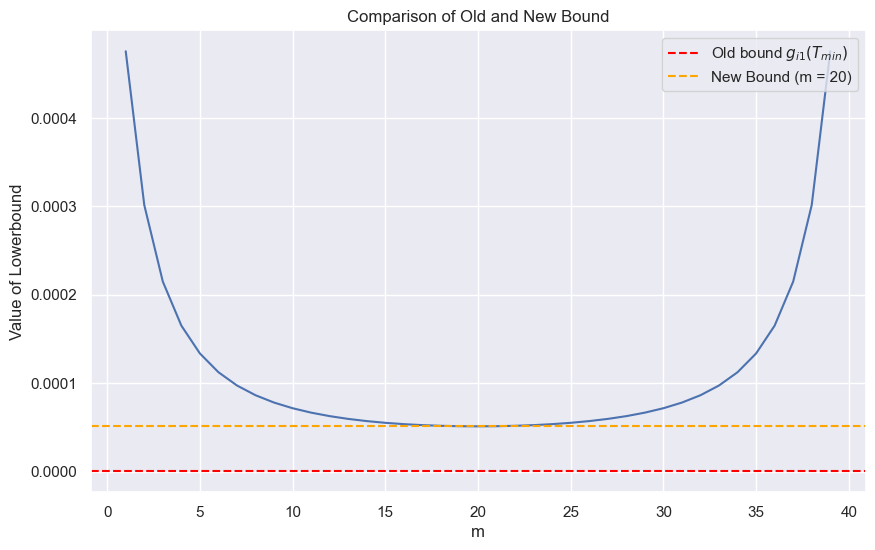

154.36980775745354

In [16]:
i_val = 40
T_min = 0.2
plot_one_step_analysis_improved(i_val, T_min)

Let's look at how much improvement we get as a function of $T_{min}$. Again, we expect the previous bound to be the worst for small values of $T_{min}$. Moreover, as we observe below the new bound is drastically better if we have more species involved.

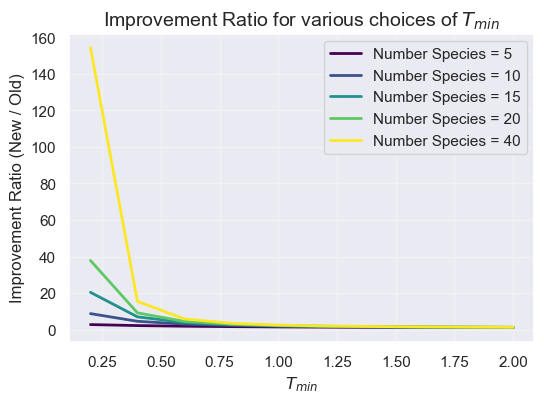

In [17]:
i_values = [5, 10, 15, 20, 40]  # Different numbers of lineages
T_vals = np.linspace(0.2, 2, 10)
colors = plt.cm.viridis(np.linspace(0, 1, len(i_values)))

plt.figure(figsize=(6, 4))

for idx, i_val in enumerate(i_values):
    ratios = []
    for t in T_vals:
        ratio = plot_one_step_analysis_improved(i_val, t, make_plot=False)
        ratios.append(ratio)
    
    plt.plot(T_vals, ratios, '-', color=colors[idx], linewidth=2, 
             label=f'Number Species = {i_val}')

plt.xlabel('$T_{min}$', fontsize=12)
plt.ylabel('Improvement Ratio (New / Old)', fontsize=12)
plt.title('Improvement Ratio for various choices of $T_{min}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Cool now it seems like we have discovered a real improvement. Moreover, note that the minimizer appears to be at the center $m=i/2$ corrresponding an even split. This maybe suggests if we wish to extend this analysis to deeper trees that the balanced tree, where all splits are as even as possible, will certainly be the worst-case.

## Properties of $g_{ij}$

In the following sections, we evaluate properties of the function $g_{ij}$. Recall we have the explicit formula:

$$g_{ij}(T) := \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}j_{(k-1)} i_{[k]}}{j!(k-j)!i_{(k)}}$$

#### Log-Convexity of $g_{i1}$

I want to investigate if the function $i \mapsto g_{i1}(T)$ is log convex for a fixed $T$. The below graph is convex on a log plot so it appears empirically it is at least log-convex.

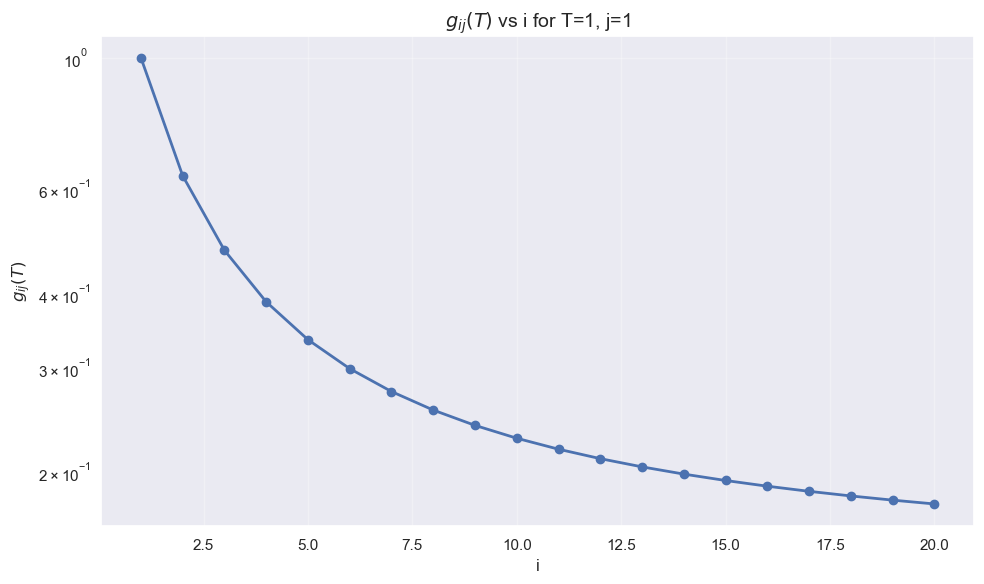

In [18]:
T_min = 1
_ = plot_g_ij_vs_i(T_min, 1, i_range=None, max_i=20, log_plot=True)

#### Q2

Is the function $g_{m,r}g_{k-m,s}$ decreasing in $m$ for each choices of $r,s$?
* This is true if either $r,s = 1$ but if both $r > 1$ and $s > 1$ it is no longer true it appears.

In [19]:
# set parameters
r = 1
s = 6
k = 20
T = 1

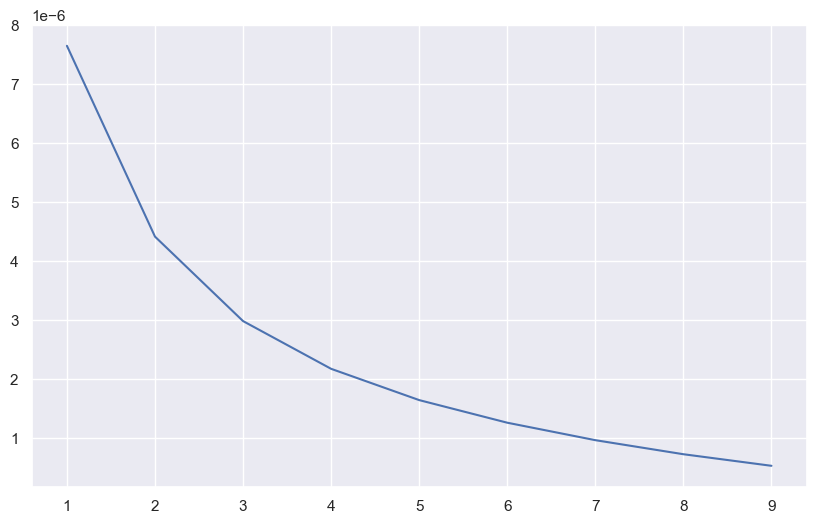

In [20]:
m_range = range(1, (k+1) // 2)

y_vals = []
for m in m_range:
    next_val = g_ij(T, m, r) * g_ij(T, k-m, s) * g_ij(T, r+s, 1)
    y_vals.append(next_val)
    
plt.plot(m_range, y_vals)

#### TODO:


Now I want to check that my function $q_\ell$ is actually decreasing because this is necessary for the proof to carry through. I thought I ought to check it empirically first before wastying some time trying to prove it.

Analyzing q_ell properties...

=== Analysis for T_min = 1.0 ===
q_2 = 0.632121
q_3 = 0.573611
q_4 = 0.524991
q_5 = 0.500296
q_6 = 0.478014
q_7 = 0.464482
q_8 = 0.451807
q_9 = 0.443277
q_10 = 0.435125
q_11 = 0.429259
q_12 = 0.423584


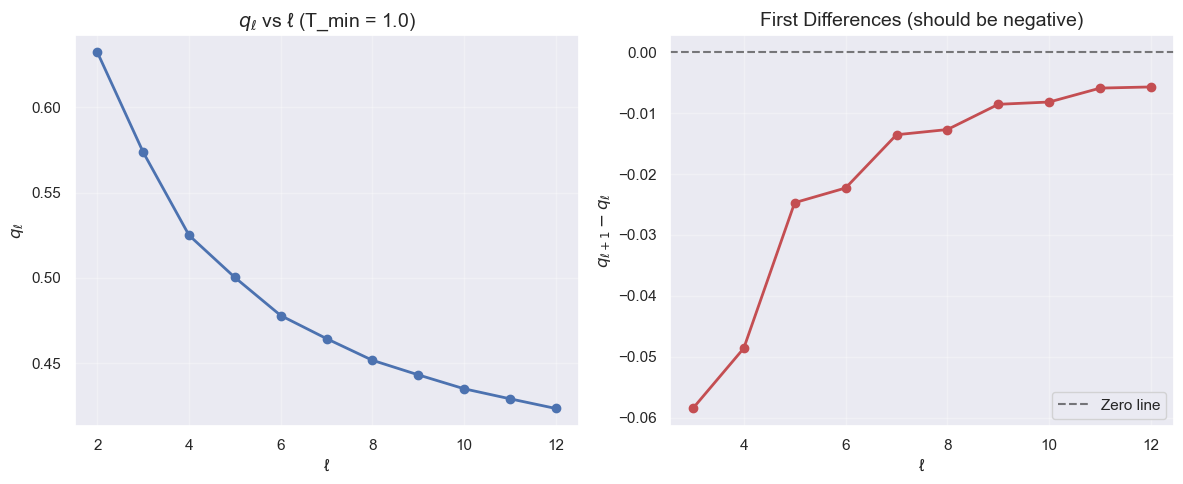


Monotonicity check:
Is q_ell decreasing? True

=== Comparison with original bound ===


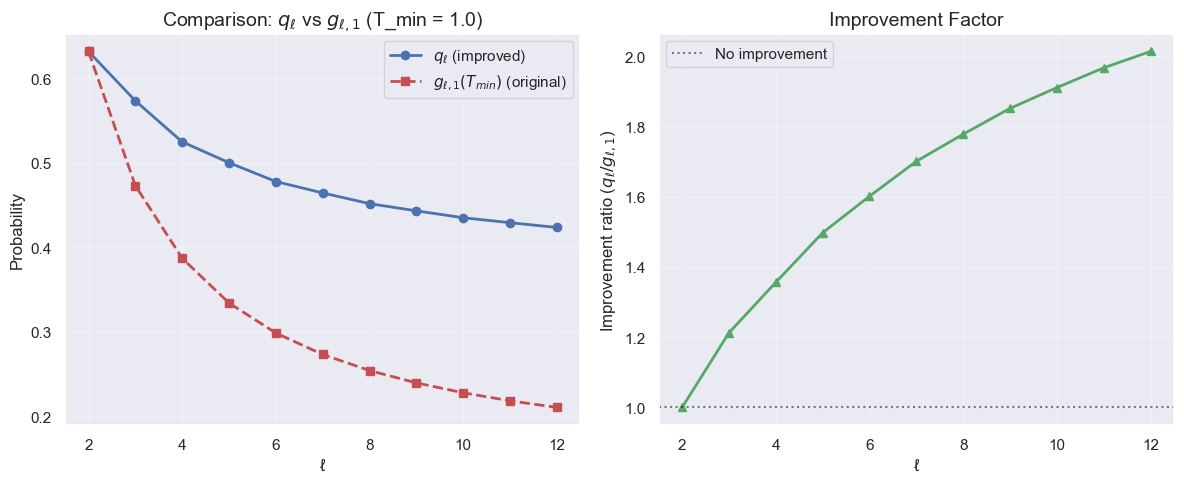


Improvement analysis for T_min = 1.0:
ℓ=2: q_ℓ=0.632121, g_ℓ1=0.632121, ratio=1.00x
ℓ=3: q_ℓ=0.573611, g_ℓ1=0.473074, ratio=1.21x
ℓ=4: q_ℓ=0.524991, g_ℓ1=0.387108, ratio=1.36x
ℓ=5: q_ℓ=0.500296, g_ℓ1=0.334129, ratio=1.50x
ℓ=6: q_ℓ=0.478014, g_ℓ1=0.298536, ratio=1.60x
ℓ=7: q_ℓ=0.464482, g_ℓ1=0.273121, ratio=1.70x
ℓ=8: q_ℓ=0.451807, g_ℓ1=0.254133, ratio=1.78x
ℓ=9: q_ℓ=0.443277, g_ℓ1=0.239443, ratio=1.85x
ℓ=10: q_ℓ=0.435125, g_ℓ1=0.227761, ratio=1.91x
ℓ=11: q_ℓ=0.429259, g_ℓ1=0.218260, ratio=1.97x
ℓ=12: q_ℓ=0.423584, g_ℓ1=0.210389, ratio=2.01x

=== Analysis across multiple T values ===


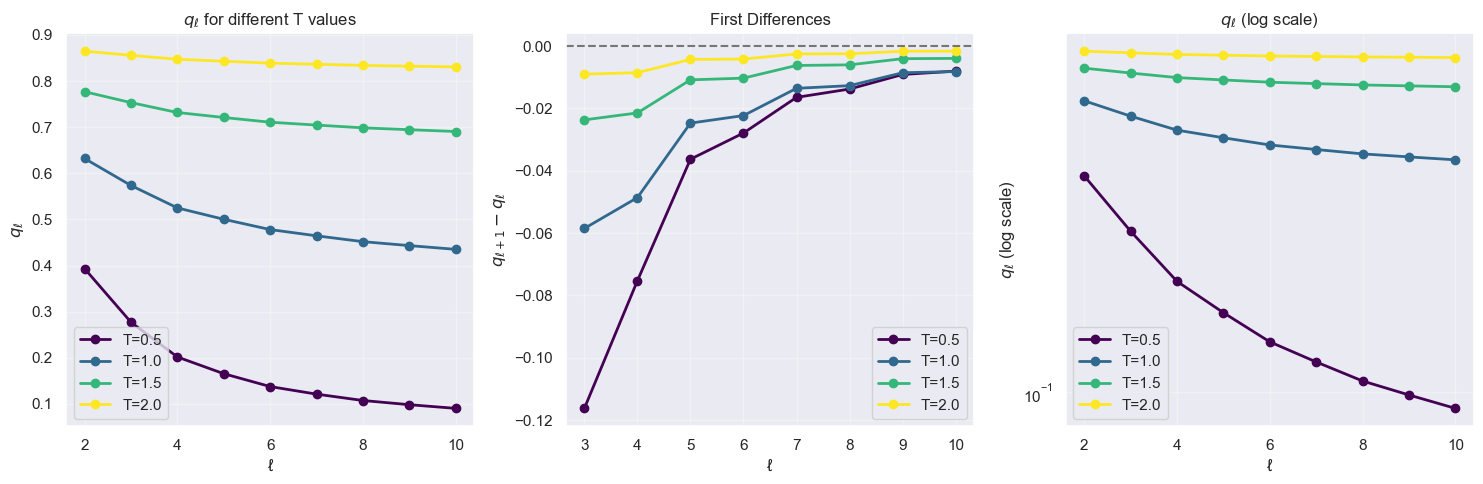

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_q_ell(ell, T_min):
    """
    Calculate q_ell according to the formula:
    q_ell = sum_{r=1}^{m(ell)} sum_{s=1}^{ell-m(ell)} g_{m(ell),r}(T_min) * g_{ell-m(ell),s}(T_min) * g_{r+s,1}(T_min)
    where m(ell) = floor(ell/2)
    """
    m_ell = ell // 2  # floor(ell/2)
    
    total_sum = 0.0
    
    for r in range(1, m_ell + 1):
        for s in range(1, (ell - m_ell) + 1):
            # Calculate each term in the double sum
            term1 = g_ij(T_min, m_ell, r)           # g_{m(ell),r}(T_min)
            term2 = g_ij(T_min, ell - m_ell, s)     # g_{ell-m(ell),s}(T_min)  
            term3 = g_ij(T_min, r + s, 1)           # g_{r+s,1}(T_min)
            
            total_sum += term1 * term2 * term3
    
    return total_sum

def plot_q_ell_verification(T_min, max_ell=15):
    """
    Plot q_ell vs ell and verify it's decreasing
    """
    ell_values = list(range(2, max_ell + 1))
    q_values = []
    
    # Calculate q_ell for each ell
    for ell in ell_values:
        q_val = calculate_q_ell(ell, T_min)
        q_values.append(q_val)
        print(f"q_{ell} = {q_val:.6f}")
    
    # Plot the results
    plt.figure(figsize=(12, 5))
    
    # Main plot
    plt.subplot(1, 2, 1)
    plt.plot(ell_values, q_values, 'bo-', linewidth=2, markersize=6)
    plt.xlabel('ℓ', fontsize=12)
    plt.ylabel('$q_ℓ$', fontsize=12)
    plt.title(f'$q_ℓ$ vs ℓ (T_min = {T_min})', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Check if decreasing
    plt.subplot(1, 2, 2)
    differences = [q_values[i+1] - q_values[i] for i in range(len(q_values)-1)]
    plt.plot(ell_values[1:], differences, 'ro-', linewidth=2, markersize=6)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Zero line')
    plt.xlabel('ℓ', fontsize=12)
    plt.ylabel('$q_{ℓ+1} - q_ℓ$', fontsize=12)
    plt.title('First Differences (should be negative)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Verify monotonicity
    is_decreasing = all(diff <= 0 for diff in differences)
    print(f"\nMonotonicity check:")
    print(f"Is q_ell decreasing? {is_decreasing}")
    
    if not is_decreasing:
        print("Warning: q_ell is not monotonically decreasing!")
        for i, diff in enumerate(differences):
            if diff > 0:
                print(f"  Increase at ℓ={ell_values[i]} to ℓ={ell_values[i+1]}: {diff:.6f}")
    
    return ell_values, q_values, differences

def compare_q_ell_with_g_ell(T_min, max_ell=15):
    """
    Compare q_ell with g_{ell,1}(T_min) to verify the improvement
    """
    ell_values = list(range(2, max_ell + 1))
    q_values = []
    g_values = []
    
    for ell in ell_values:
        q_val = calculate_q_ell(ell, T_min)
        g_val = g_ij(T_min, ell, 1)
        q_values.append(q_val)
        g_values.append(g_val)
    
    plt.figure(figsize=(12, 5))
    
    # Comparison plot
    plt.subplot(1, 2, 1)
    plt.plot(ell_values, q_values, 'b-o', linewidth=2, label='$q_ℓ$ (improved)')
    plt.plot(ell_values, g_values, 'r--s', linewidth=2, label='$g_{ℓ,1}(T_{min})$ (original)')
    plt.xlabel('ℓ', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.title(f'Comparison: $q_ℓ$ vs $g_{{ℓ,1}}$ (T_min = {T_min})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Improvement ratio
    plt.subplot(1, 2, 2)
    improvement_ratios = [q/g if g > 0 else 0 for q, g in zip(q_values, g_values)]
    plt.plot(ell_values, improvement_ratios, 'g-^', linewidth=2, markersize=6)
    plt.axhline(1, color='black', linestyle=':', alpha=0.5, label='No improvement')
    plt.xlabel('ℓ', fontsize=12)
    plt.ylabel('Improvement ratio ($q_ℓ / g_{ℓ,1}$)', fontsize=12)
    plt.title('Improvement Factor', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nImprovement analysis for T_min = {T_min}:")
    for i, (ell, q, g, ratio) in enumerate(zip(ell_values, q_values, g_values, improvement_ratios)):
        print(f"ℓ={ell}: q_ℓ={q:.6f}, g_ℓ1={g:.6f}, ratio={ratio:.2f}x")

def analyze_multiple_T_values(T_values, max_ell=12):
    """
    Analyze q_ell behavior across multiple T values
    """
    plt.figure(figsize=(15, 5))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(T_values)))
    
    for idx, T_min in enumerate(T_values):
        ell_values = list(range(2, max_ell + 1))
        q_values = [calculate_q_ell(ell, T_min) for ell in ell_values]
        
        plt.subplot(1, 3, 1)
        plt.plot(ell_values, q_values, 'o-', color=colors[idx], 
                linewidth=2, label=f'T={T_min}')
    
    plt.xlabel('ℓ')
    plt.ylabel('$q_ℓ$')
    plt.title('$q_ℓ$ for different T values')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Check monotonicity for each T
    plt.subplot(1, 3, 2)
    for idx, T_min in enumerate(T_values):
        ell_values = list(range(2, max_ell + 1))
        q_values = [calculate_q_ell(ell, T_min) for ell in ell_values]
        differences = [q_values[i+1] - q_values[i] for i in range(len(q_values)-1)]
        
        plt.plot(ell_values[1:], differences, 'o-', color=colors[idx], 
                linewidth=2, label=f'T={T_min}')
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('ℓ')
    plt.ylabel('$q_{ℓ+1} - q_ℓ$')
    plt.title('First Differences')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Log scale comparison
    plt.subplot(1, 3, 3)
    for idx, T_min in enumerate(T_values):
        ell_values = list(range(2, max_ell + 1))
        q_values = [calculate_q_ell(ell, T_min) for ell in ell_values]
        
        plt.semilogy(ell_values, q_values, 'o-', color=colors[idx], 
                    linewidth=2, label=f'T={T_min}')
    
    plt.xlabel('ℓ')
    plt.ylabel('$q_ℓ$ (log scale)')
    plt.title('$q_ℓ$ (log scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage
print("Analyzing q_ell properties...")

# Single T value analysis
T_min = 1.0
print(f"\n=== Analysis for T_min = {T_min} ===")
ell_vals, q_vals, diffs = plot_q_ell_verification(T_min, max_ell=12)

# Compare with original bound
print(f"\n=== Comparison with original bound ===")
compare_q_ell_with_g_ell(T_min, max_ell=12)

# Multiple T values
print(f"\n=== Analysis across multiple T values ===")
T_values = [0.5, 1.0, 1.5, 2.0]
analyze_multiple_T_values(T_values, max_ell=10)

Now that we observe $q_\ell$ is decreasing, its time to prove it hopefully.

Analyzing the sum function...

=== Analysis for x = 3 ===
Calculating sum function for x = 3, T_min = 1.0
ℓ	floor(ℓ/2)	ceil(ℓ/2)	upper_limit	sum_value
------------------------------------------------------------
2	1		1		1		0.000000
3	1		2		1		0.367879
4	2		2		2		0.465088
5	2		3		2		0.475643
6	3		3		3		0.451444
7	3		4		3		0.428714
8	4		4		3		0.399338
9	4		5		3		0.377429
10	5		5		3		0.354037
11	5		6		3		0.336551
12	6		6		3		0.318773
13	6		7		3		0.305154
14	7		7		3		0.291543
15	7		8		3		0.280848


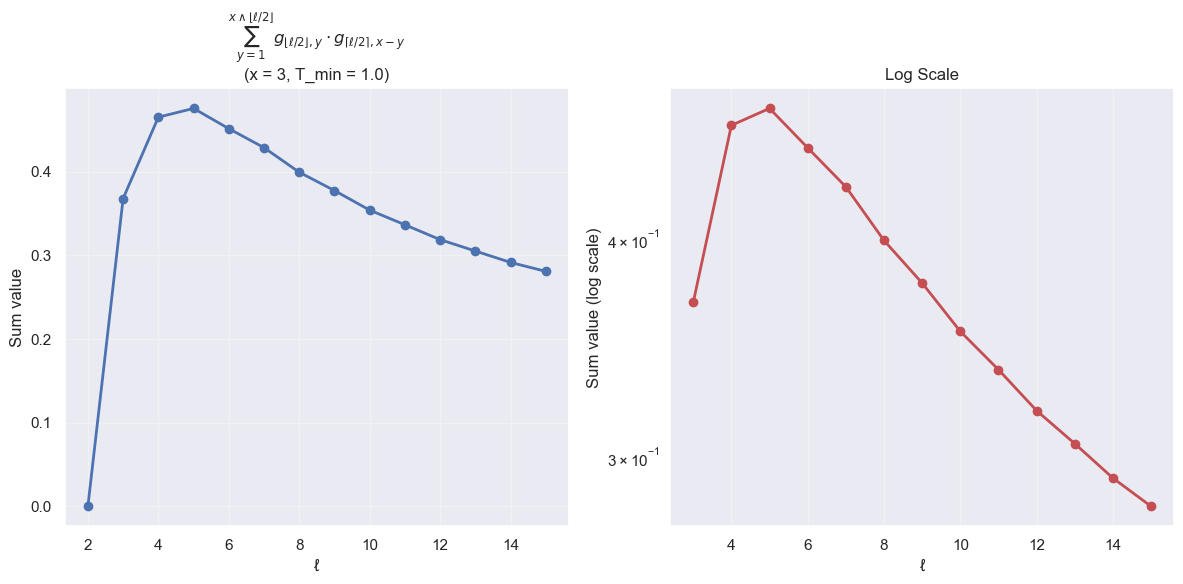


=== Comparison across multiple x values ===


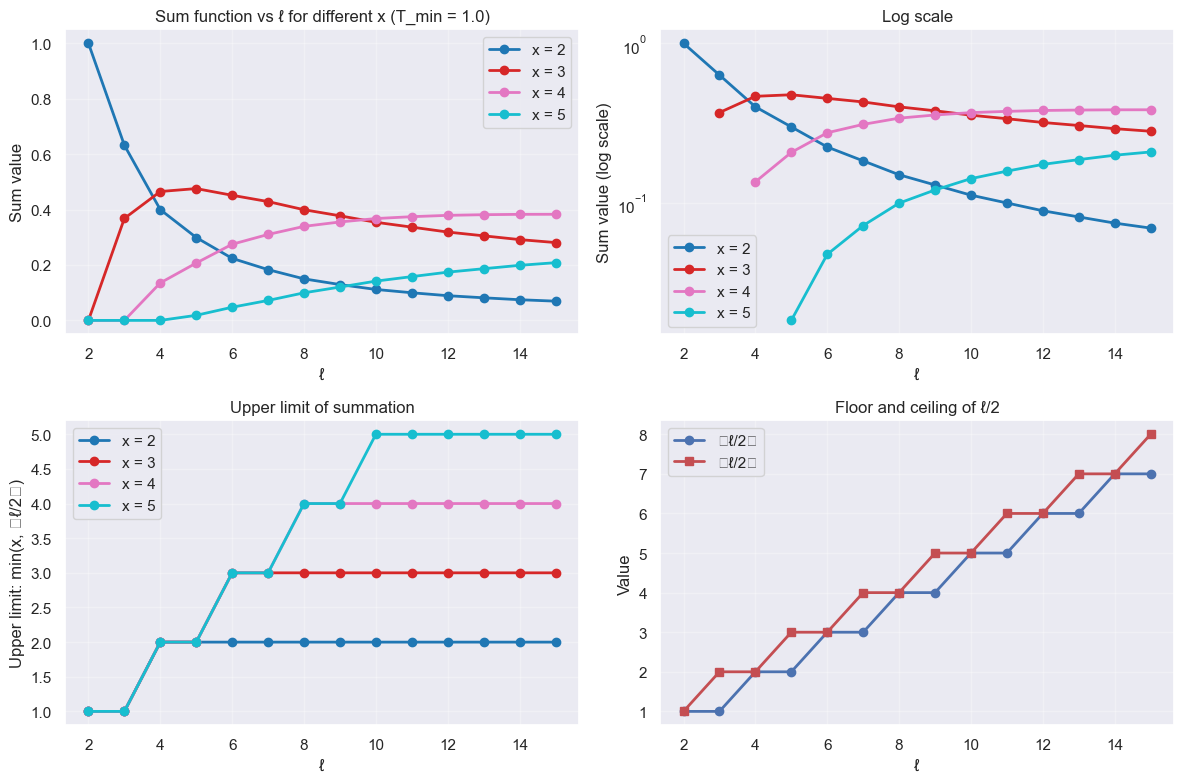


=== Detailed structure analysis ===

Detailed analysis for x = 3, ℓ = 8, T_min = 1.0
⌊ℓ/2⌋ = 4
⌈ℓ/2⌉ = 4
x ∧ ⌊ℓ/2⌋ = min(3, 4) = 3
Sum runs from y = 1 to y = 3

y	x-y	g_{⌊ℓ/2⌋,y}	g_{⌈ℓ/2⌉,x-y}	Product
------------------------------------------------------------
1	2	0.387108	0.515796		0.199669
2	1	0.515796	0.387108		0.199669
3	0	--		--		0 (x-y ≤ 0)
------------------------------------------------------------
Total sum: 0.399338


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_sum_function(ell, x, T_min):
    """
    Calculate sum_{y=1}^{x ∧ floor(ell/2)} g_{floor(ell/2), y} * g_{ceil(ell/2), x-y}
    where x ∧ floor(ell/2) means min(x, floor(ell/2))
    """
    floor_ell_half = ell // 2
    ceil_ell_half = math.ceil(ell / 2)
    
    # Upper limit of sum: min(x, floor(ell/2))
    upper_limit = min(x, floor_ell_half)
    
    total_sum = 0.0
    
    for y in range(1, upper_limit + 1):
        if x - y > 0:  # Ensure x-y is positive for g function
            term1 = g_ij(T_min, floor_ell_half, y)      # g_{floor(ell/2), y}
            term2 = g_ij(T_min, ceil_ell_half, x - y)   # g_{ceil(ell/2), x-y}
            total_sum += term1 * term2
    
    return total_sum

def plot_sum_vs_ell(x_fixed, T_min, ell_range):
    """
    Plot the sum function vs ell for fixed x
    """
    ell_values = list(ell_range)
    sum_values = []
    
    print(f"Calculating sum function for x = {x_fixed}, T_min = {T_min}")
    print("ℓ\tfloor(ℓ/2)\tceil(ℓ/2)\tupper_limit\tsum_value")
    print("-" * 60)
    
    for ell in ell_values:
        sum_val = calculate_sum_function(ell, x_fixed, T_min)
        sum_values.append(sum_val)
        
        # Debug info
        floor_ell_half = ell // 2
        ceil_ell_half = math.ceil(ell / 2)
        upper_limit = min(x_fixed, floor_ell_half)
        print(f"{ell}\t{floor_ell_half}\t\t{ceil_ell_half}\t\t{upper_limit}\t\t{sum_val:.6f}")
    
    plt.figure(figsize=(12, 6))
    
    # Main plot
    plt.subplot(1, 2, 1)
    plt.plot(ell_values, sum_values, 'bo-', linewidth=2, markersize=6)
    plt.xlabel('ℓ', fontsize=12)
    plt.ylabel('Sum value', fontsize=12)
    plt.title(f'$\sum_{{y=1}}^{{x \\wedge \\lfloor \\ell/2 \\rfloor}} g_{{\\lfloor \\ell/2 \\rfloor, y}} \cdot g_{{\\lceil \\ell/2 \\rceil, x-y}}$\n(x = {x_fixed}, T_min = {T_min})', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Log scale plot
    plt.subplot(1, 2, 2)
    # Filter out zero values for log plot
    non_zero_ell = [ell for ell, val in zip(ell_values, sum_values) if val > 0]
    non_zero_values = [val for val in sum_values if val > 0]
    
    if non_zero_values:
        plt.semilogy(non_zero_ell, non_zero_values, 'ro-', linewidth=2, markersize=6)
        plt.xlabel('ℓ', fontsize=12)
        plt.ylabel('Sum value (log scale)', fontsize=12)
        plt.title('Log Scale', fontsize=12)
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'All values are zero', transform=plt.gca().transAxes, 
                ha='center', va='center', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    return ell_values, sum_values

def plot_multiple_x_values(x_values, T_min, ell_range):
    """
    Plot the sum function for multiple x values on the same graph
    """
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(x_values)))
    
    plt.subplot(2, 2, 1)
    for idx, x in enumerate(x_values):
        ell_vals = list(ell_range)
        sum_vals = [calculate_sum_function(ell, x, T_min) for ell in ell_vals]
        plt.plot(ell_vals, sum_vals, 'o-', color=colors[idx], 
                linewidth=2, label=f'x = {x}')
    
    plt.xlabel('ℓ')
    plt.ylabel('Sum value')
    plt.title(f'Sum function vs ℓ for different x (T_min = {T_min})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Log scale
    plt.subplot(2, 2, 2)
    for idx, x in enumerate(x_values):
        ell_vals = list(ell_range)
        sum_vals = [calculate_sum_function(ell, x, T_min) for ell in ell_vals]
        # Filter positive values
        pos_ell = [ell for ell, val in zip(ell_vals, sum_vals) if val > 0]
        pos_vals = [val for val in sum_vals if val > 0]
        if pos_vals:
            plt.semilogy(pos_ell, pos_vals, 'o-', color=colors[idx], 
                        linewidth=2, label=f'x = {x}')
    
    plt.xlabel('ℓ')
    plt.ylabel('Sum value (log scale)')
    plt.title('Log scale')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Show the upper limit behavior
    plt.subplot(2, 2, 3)
    ell_vals = list(ell_range)
    for idx, x in enumerate(x_values):
        upper_limits = [min(x, ell // 2) for ell in ell_vals]
        plt.plot(ell_vals, upper_limits, 'o-', color=colors[idx], 
                linewidth=2, label=f'x = {x}')
    
    plt.xlabel('ℓ')
    plt.ylabel('Upper limit: min(x, ⌊ℓ/2⌋)')
    plt.title('Upper limit of summation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Show floor and ceil behavior
    plt.subplot(2, 2, 4)
    ell_vals = list(ell_range)
    floor_vals = [ell // 2 for ell in ell_vals]
    ceil_vals = [math.ceil(ell / 2) for ell in ell_vals]
    
    plt.plot(ell_vals, floor_vals, 'b-o', linewidth=2, label='⌊ℓ/2⌋')
    plt.plot(ell_vals, ceil_vals, 'r-s', linewidth=2, label='⌈ℓ/2⌉')
    plt.xlabel('ℓ')
    plt.ylabel('Value')
    plt.title('Floor and ceiling of ℓ/2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_sum_structure(x_fixed, T_min, ell_test):
    """
    Analyze the structure of the sum for a specific ell value
    """
    print(f"\nDetailed analysis for x = {x_fixed}, ℓ = {ell_test}, T_min = {T_min}")
    print("=" * 60)
    
    floor_ell_half = ell_test // 2
    ceil_ell_half = math.ceil(ell_test / 2)
    upper_limit = min(x_fixed, floor_ell_half)
    
    print(f"⌊ℓ/2⌋ = {floor_ell_half}")
    print(f"⌈ℓ/2⌉ = {ceil_ell_half}")
    print(f"x ∧ ⌊ℓ/2⌋ = min({x_fixed}, {floor_ell_half}) = {upper_limit}")
    print(f"Sum runs from y = 1 to y = {upper_limit}")
    print()
    
    if upper_limit >= 1:
        print("y\tx-y\tg_{⌊ℓ/2⌋,y}\tg_{⌈ℓ/2⌉,x-y}\tProduct")
        print("-" * 60)
        
        total = 0.0
        for y in range(1, upper_limit + 1):
            if x_fixed - y > 0:
                g1 = g_ij(T_min, floor_ell_half, y)
                g2 = g_ij(T_min, ceil_ell_half, x_fixed - y)
                product = g1 * g2
                total += product
                print(f"{y}\t{x_fixed-y}\t{g1:.6f}\t{g2:.6f}\t\t{product:.6f}")
            else:
                print(f"{y}\t{x_fixed-y}\t--\t\t--\t\t0 (x-y ≤ 0)")
        
        print("-" * 60)
        print(f"Total sum: {total:.6f}")
    else:
        print("No terms in sum (upper limit < 1)")

# Example usage
print("Analyzing the sum function...")

# Parameters
T_min = 1.0
x_fixed = 3
ell_range = range(2, 16)

# Single x analysis
print(f"\n=== Analysis for x = {x_fixed} ===")
ell_vals, sum_vals = plot_sum_vs_ell(x_fixed, T_min, ell_range)

# Multiple x values
print(f"\n=== Comparison across multiple x values ===")
x_values = [2, 3, 4, 5]
plot_multiple_x_values(x_values, T_min, ell_range)

# Detailed structure analysis
print(f"\n=== Detailed structure analysis ===")
analyze_sum_structure(x_fixed, T_min, ell_test=8)

## Log-Concavity

We were wondering if the distribution $X_T$ of surviving lineages for a tree $T$ was log-concave regardless of the tree topology $T$. I am specifically interested in the case $T$ is a balanced tree, in which case we can calculate the distributions of the $X_m = Z_{X_{m/2}} + Z_{X_{m/2}}$ recursively.

Our code below seems to suggest the $X_m$ are indeed log-concave.

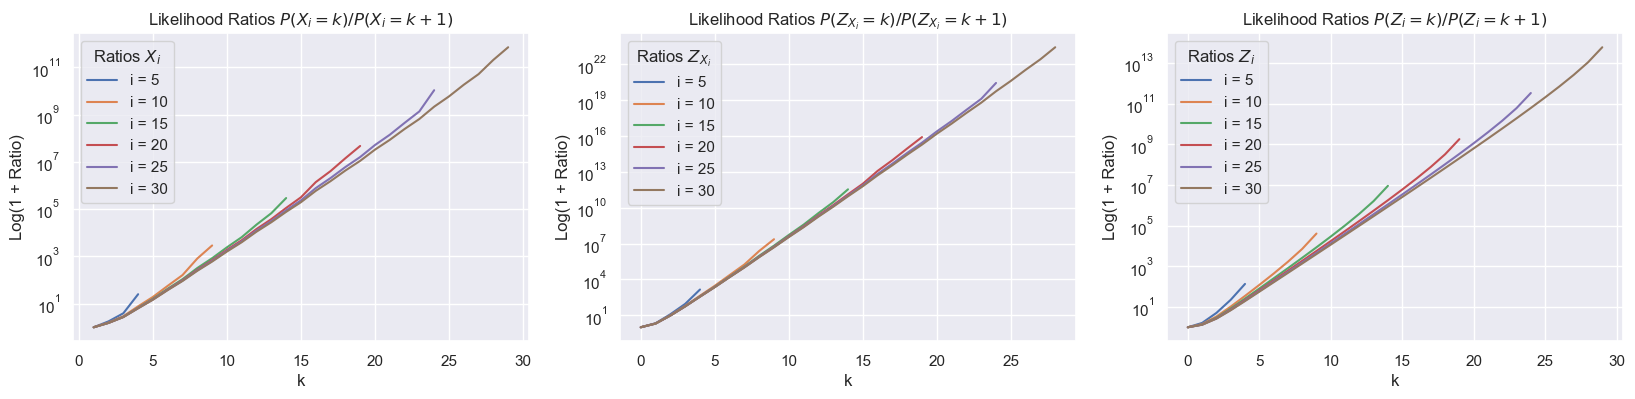

In [27]:
def check_log_concavity(i_vals, T, log_plot=True):
    """
        Calculates the distributions of X_m and Z_{X_m} for our balanced binary trees with m leaves.
        
        Recall that:
            
            X_i = Z_{floor(i/2)} + Z_{ceil(i/2)}
            P(Z_i = j) = E g_{X_i, j}(T)
            
        Plots the ratios P(X_i = k) / P(X_i = k+1) as functions of k for each of the provided i_values
        
    """
    m_max = max(i_vals)
 
    # Pre-calculate g_ij values: entry g[i,j] stores g_ij(T_min)
    g_array = np.full((m_max + 1, m_max + 1), 0.0)
    for i in range(1, m_max + 1):
        for j in range(1, i+1):
            g_array[i, j] = g_ij(T, i, j)
            
    # allocate space for distributions Z_i
    # z_array[i,j] = P(Z_i = j)
    # x_array[i, j] = P(X_i = j)
    z_array = np.zeros((m_max+1, m_max+1))
    x_array = np.zeros((m_max+1, m_max+1))
    
    # Set base case:
    z_array[1, 1] = 1
    x_array[1,1] =  1
    
    for i in range(2, m_max+1):
        
        l = i // 2
        r = (i+1) // 2
        
        # calculate sum distribution
        x_array[i, :] = np.convolve(z_array[l, :], z_array[r,:], mode='full')[:m_max+1]
        
        # calculate new distribution
        z_array[i, :] = x_array[i, :] @ g_array
    

        
    fig, axs = plt.subplots(1,3, figsize=(20,4))
    
    # Plot ratios for X_i
    ax = axs[0]
    for i in i_vals:
        # Plot P(X_i = k) / P(X_i = k+1) as a function of k 
        ratios = x_array[i, :-1] / x_array[i, 1:]  
        
        if log_plot:
            ax.semilogy(1 + ratios, label=f'i = {i}')
        else:
            ax.plot(ratios, label=f'i = {i}')
    
    ax.set_title('Likelihood Ratios $P(X_i = k) / P(X_i = k+1)$')
    ax.legend(title='Ratios $X_i$')
    if log_plot:
        ax.set_ylabel('Log(1 + Ratio)')
    else:
        ax.set_ylabel('Ratio')
    ax.set_xlabel('k')
    
    
    # Plot ratios for Z_{X_i}
    ax = axs[1]
    for i in i_vals:
        # Plot P(Z_{X_i} = k) / P(Z_{X_i} = k+1) as a function of k 
        ratios = z_array[i, :-1] / z_array[i, 1:]  
        
        if log_plot:
            ax.semilogy(1 + ratios, label=f'i = {i}')
        else:
            ax.plot(ratios, label=f'i = {i}')
    
    ax.set_title('Likelihood Ratios $P(Z_{X_i} = k) / P(Z_{X_i} = k+1)$')
    ax.legend(title='Ratios $Z_{X_i}$')
    if log_plot:
        ax.set_ylabel('Log(1 + Ratio)')
    else:
        ax.set_ylabel('Ratio')
    ax.set_xlabel('k')
    
    # Plot ratios for Z_i
    ax = axs[2]
    for i in i_vals:
        # Plot P(Z_i = k) / P(Z_i = k+1) as a function of k 
        ratios = g_array[i, :-1] / g_array[i, 1:]  
        
        if log_plot:
            ax.semilogy(1 + ratios, label=f'i = {i}')
        else:
            ax.plot(ratios, label=f'i = {i}')
    
    ax.set_title('Likelihood Ratios $P(Z_i = k) / P(Z_i = k+1)$')
    ax.legend(title='Ratios $Z_i$')
    if log_plot:
        ax.set_ylabel('Log(1 + Ratio)')
    else:
        ax.set_ylabel('Ratio')
    ax.set_xlabel('k')
    
    plt.show()
    
i_vals_to_plot = list(range(5,35, 5))
check_log_concavity(i_vals_to_plot, 1)

In [24]:
1/np.e**2

0.1353352832366127

### Total Positivity of $g_{ij}(T)$.

Here we check whether the matrix is totally positive in the sense:

$$g_{ij}(T) \cdot g_{i'j'}(T) \geq g_{ij'}(T) \cdot g_{i'j}(T) \qquad \forall i < i', j < j'$$

Testing TP₂ condition for g_ij(T) as a matrix in (i,j)

T = 0.5
----------------------------------------
  Total 2×2 minors checked: 308
  Violations found: 0
  Minimum ratio (LHS/RHS): 1.0996727361
  ✓ All TP₂ conditions satisfied!

T = 1.0
----------------------------------------
  Total 2×2 minors checked: 308
  Violations found: 0
  Minimum ratio (LHS/RHS): 1.0000000000
  ✓ All TP₂ conditions satisfied!

T = 2.0
----------------------------------------
  Total 2×2 minors checked: 308
  Violations found: 0
  Minimum ratio (LHS/RHS): 1.0000000000
  ✓ All TP₂ conditions satisfied!

T = 3.0
----------------------------------------
  Total 2×2 minors checked: 308
  Violations found: 0
  Minimum ratio (LHS/RHS): 1.0000000000
  ✓ All TP₂ conditions satisfied!

Detailed analysis for T = 0.05


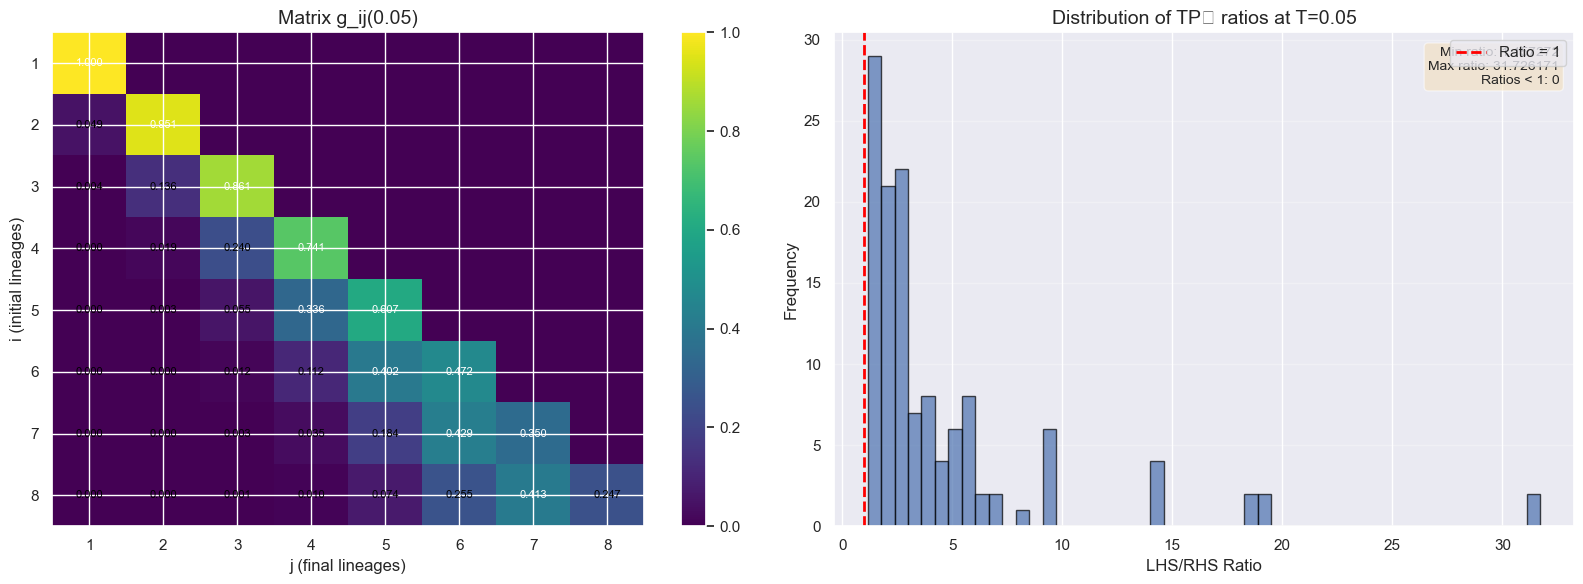


Ratio distribution:
  ≥1.01: 126
  1.00-1.01: 0
  0.99-1.00: 0
  <0.99: 0

CONCLUSION: g_ij(T) as a matrix in (i,j) appears to be TP₂ for the tested T values!


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, exp

def check_tp2_condition(T, i1, i2, j1, j2):
    """
    Check TP₂ condition for matrix g_ij(T) viewed as function of (i,j):
    g(i1,j1) * g(i2,j2) >= g(i1,j2) * g(i2,j1)
    for i1 < i2 and j1 < j2
    
    Returns: (satisfied, LHS, RHS, ratio)
    """
    g_i1_j1 = g_ij(T, i1, j1)
    g_i2_j2 = g_ij(T, i2, j2)
    g_i1_j2 = g_ij(T, i1, j2)
    g_i2_j1 = g_ij(T, i2, j1)
    
    LHS = g_i1_j1 * g_i2_j2
    RHS = g_i1_j2 * g_i2_j1
    
    # Check if TP₂ condition is satisfied
    satisfied = LHS >= RHS - 1e-10  # Small tolerance for numerical errors
    
    # Compute ratio for analysis
    if RHS > 1e-15:
        ratio = LHS / RHS
    else:
        ratio = float('inf') if LHS > 1e-15 else 1.0
    
    return satisfied, LHS, RHS, ratio

# Test TP₂ for various T values
T_test_values = [0.5, 1.0, 2.0, 3.0]
max_i = 8  # Test up to 8 lineages

print("Testing TP₂ condition for g_ij(T) as a matrix in (i,j)")
print("=" * 80)

for T in T_test_values:
    print(f"\nT = {T}")
    print("-" * 40)
    
    violations = []
    min_ratio = float('inf')
    total_checks = 0
    
    # Check all 2x2 minors for this T
    for i1 in range(2, max_i + 1):  # i1 from 2 to max_i
        for i2 in range(i1 + 1, max_i + 1):  # i2 > i1
            for j1 in range(1, i1 + 1):  # j1 can be 1 to i1
                for j2 in range(j1 + 1, i2 + 1):  # j2 > j1 and j2 <= i2
                    total_checks += 1
                    satisfied, LHS, RHS, ratio = check_tp2_condition(T, i1, i2, j1, j2)
                    
                    if ratio < min_ratio and ratio != float('inf'):
                        min_ratio = ratio
                    
                    if not satisfied:
                        violations.append({
                            'i1': i1, 'i2': i2, 'j1': j1, 'j2': j2,
                            'LHS': LHS, 'RHS': RHS, 'ratio': ratio
                        })
    
    print(f"  Total 2×2 minors checked: {total_checks}")
    print(f"  Violations found: {len(violations)}")
    print(f"  Minimum ratio (LHS/RHS): {min_ratio:.10f}")
    
    if len(violations) > 0:
        print(f"  First 5 violations:")
        for v in violations[:5]:
            print(f"    i1={v['i1']}, i2={v['i2']}, j1={v['j1']}, j2={v['j2']}")
            print(f"      LHS={v['LHS']:.6e}, RHS={v['RHS']:.6e}, ratio={v['ratio']:.10f}")
    else:
        print(f"  ✓ All TP₂ conditions satisfied!")

# Create a detailed visualization for one specific T
T_viz = 0.05
print(f"\n{'=' * 80}")
print(f"Detailed analysis for T = {T_viz}")
print(f"{'=' * 80}")

# Create a heatmap of g_ij values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Matrix of g_ij values
max_i_viz = 8
matrix_vals = np.zeros((max_i_viz, max_i_viz))
for i in range(1, max_i_viz + 1):
    for j in range(1, i + 1):
        matrix_vals[i-1, j-1] = g_ij(T_viz, i, j)

im1 = axes[0].imshow(matrix_vals, cmap='viridis', aspect='auto')
axes[0].set_xlabel('j (final lineages)', fontsize=12)
axes[0].set_ylabel('i (initial lineages)', fontsize=12)
axes[0].set_title(f'Matrix g_ij({T_viz})', fontsize=14)
axes[0].set_xticks(range(max_i_viz))
axes[0].set_yticks(range(max_i_viz))
axes[0].set_xticklabels(range(1, max_i_viz + 1))
axes[0].set_yticklabels(range(1, max_i_viz + 1))
plt.colorbar(im1, ax=axes[0])

# Add text annotations
for i in range(max_i_viz):
    for j in range(i + 1):
        val = matrix_vals[i, j]
        if val > 0:
            axes[0].text(j, i, f'{val:.3f}', ha="center", va="center", 
                        color="white" if val > 0.3 else "black", fontsize=8)

# Plot 2: Check specific 2x2 minors and show minimum ratios
ratio_counts = {'≥1.01': 0, '1.00-1.01': 0, '0.99-1.00': 0, '<0.99': 0}
all_ratios = []

for i1 in range(2, max_i_viz + 1):
    for i2 in range(i1 + 1, max_i_viz + 1):
        for j1 in range(1, i1 + 1):
            for j2 in range(j1 + 1, i2 + 1):
                _, _, _, ratio = check_tp2_condition(T_viz, i1, i2, j1, j2)
                if ratio != float('inf'):
                    all_ratios.append(ratio)
                    if ratio >= 1.01:
                        ratio_counts['≥1.01'] += 1
                    elif ratio >= 1.00:
                        ratio_counts['1.00-1.01'] += 1
                    elif ratio >= 0.99:
                        ratio_counts['0.99-1.00'] += 1
                    else:
                        ratio_counts['<0.99'] += 1

# Plot histogram of ratios
axes[1].hist(all_ratios, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1')
axes[1].set_xlabel('LHS/RHS Ratio', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Distribution of TP₂ ratios at T={T_viz}', fontsize=14)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add text summary
summary_text = f"Min ratio: {min(all_ratios):.6f}\nMax ratio: {max(all_ratios):.6f}\n"
summary_text += f"Ratios < 1: {ratio_counts['<0.99'] + ratio_counts['0.99-1.00']}"
axes[1].text(0.98, 0.97, summary_text, transform=axes[1].transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nRatio distribution:")
for range_name, count in ratio_counts.items():
    print(f"  {range_name}: {count}")

print("\n" + "=" * 80)
if min(all_ratios) >= 1.0 - 1e-10:
    print("CONCLUSION: g_ij(T) as a matrix in (i,j) appears to be TP₂ for the tested T values!")
else:
    print("CONCLUSION: TP₂ property may be VIOLATED!")
    print(f"Minimum ratio found: {min(all_ratios):.10f} < 1.0")

TP₂ Characterization: P(Z_i = k) / P(Z_i = k+1) should be DECREASING in i

T = 0.5
----------------------------------------
  Total ratio comparisons: 120
  Violations found: 0
  ✓ All ratios are decreasing in i!

T = 1.0
----------------------------------------
  Total ratio comparisons: 120
  Violations found: 0
  ✓ All ratios are decreasing in i!

T = 2.0
----------------------------------------
  Total ratio comparisons: 120
  Violations found: 0
  ✓ All ratios are decreasing in i!

T = 3.0
----------------------------------------
  Total ratio comparisons: 120
  Violations found: 0
  ✓ All ratios are decreasing in i!

Detailed visualization for T = 1.0

Monotonicity check for each k at T=1.0:
----------------------------------------
  k=1: ✓ Decreasing
         Range: [0.4333, 1.7183]
  k=2: ✓ Decreasing
         Range: [2.3665, 9.5836]
  k=3: ✓ Decreasing
         Range: [9.3727, 38.1711]
  k=4: ✓ Decreasing
         Range: [33.7457, 133.9954]
  k=5: ✓ Decreasing
         Range: 

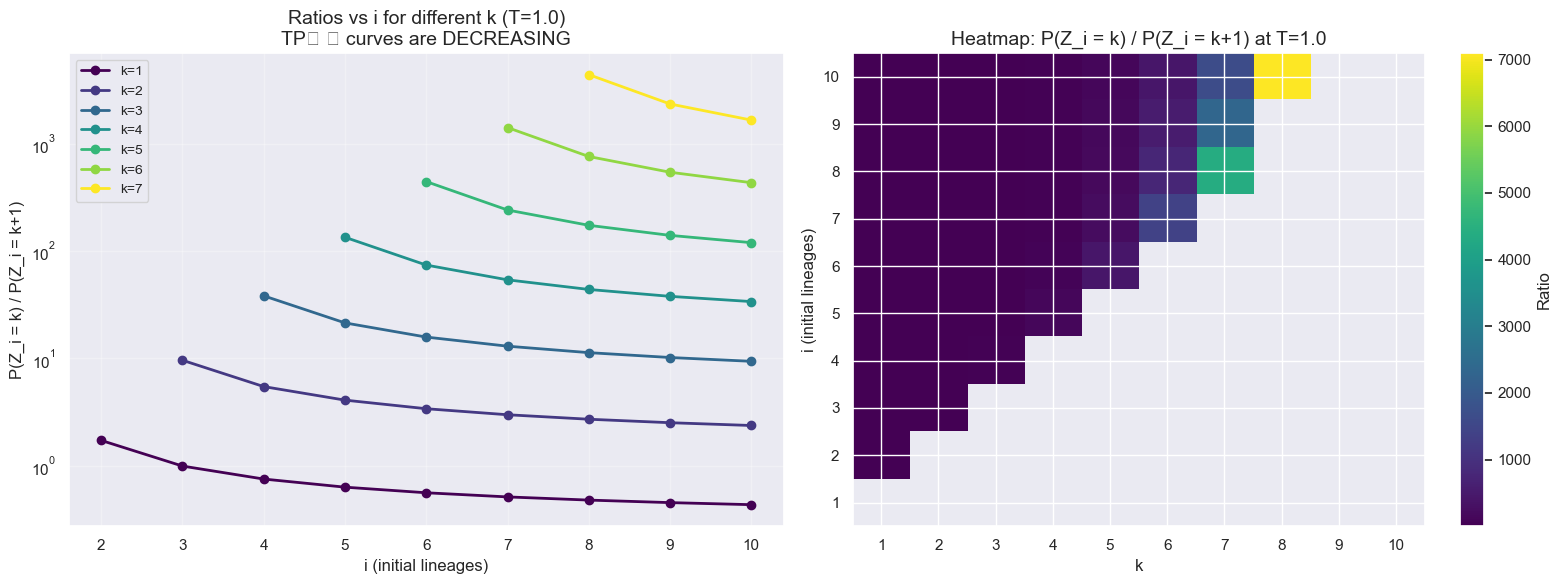


CONCLUSION:
If all ratios are DECREASING in i for each k, then g_ij(T) is TP₂ in (i,j).
This would mean the recursion preserves log-concavity in j.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, exp

def rising_factorial(a, k):
    """Calculate a^(k) = a(a+1)...(a+k-1)"""
    if k == 0:
        return 1
    result = 1
    for i in range(k):
        result *= (a + i)
    return result

def falling_factorial(a, k):
    """Calculate a^[k] = a(a-1)...(a-k+1)"""
    if k == 0:
        return 1
    result = 1
    for i in range(k):
        result *= (a - i)
    return result

def g_ij(i, j, T):
    """
    Calculate g_ij(T): probability that i lineages coalesce 
    into exactly j lineages in time T under Kingman's coalescence.
    """
    if j > i or j < 1:
        return 0.0
    
    total = 0.0
    for k in range(j, i + 1):
        exp_term = exp(-comb(k, 2) * T)
        sign = (-1) ** (k - j)
        numerator = exp_term * (2*k - 1) * sign * rising_factorial(j, k-1) * falling_factorial(i, k)
        denominator = factorial(j) * factorial(k - j) * rising_factorial(i, k)
        
        total += numerator / denominator
    
    return total

def compute_ratio(i, k, T):
    """Compute P(Z_i^T = k) / P(Z_i^T = k+1)"""
    p_k = g_ij(i, k, T)
    p_k_plus_1 = g_ij(i, k + 1, T)
    
    if p_k_plus_1 > 1e-15:
        return p_k / p_k_plus_1
    else:
        return float('inf') if p_k > 1e-15 else 1.0

# Test the TP₂ characterization: ratios should be increasing in i
print("TP₂ Characterization: P(Z_i = k) / P(Z_i = k+1) should be DECREASING in i")
print("=" * 80)

T_test_values = [0.5, 1.0, 2.0, 3.0]
max_i = 10

for T in T_test_values:
    print(f"\nT = {T}")
    print("-" * 40)
    
    violations = []
    total_checks = 0
    
    # For each k, check if ratios are DECREASING in i
    for k in range(1, max_i):
        for i1 in range(k + 1, max_i + 1):  # i1 must be > k to have k+1 lineages
            for i2 in range(i1 + 1, max_i + 1):  # i2 > i1
                if k + 1 > i1:  # Can't have k+1 lineages if i1 <= k
                    continue
                    
                total_checks += 1
                ratio_i1 = compute_ratio(i1, k, T)
                ratio_i2 = compute_ratio(i2, k, T)
                
                # TP₂ requires ratio_i1 >= ratio_i2 (ratios DECREASING in i)
                if ratio_i2 > ratio_i1 + 1e-10 and ratio_i1 != float('inf') and ratio_i2 != float('inf'):
                    violations.append({
                        'k': k, 'i1': i1, 'i2': i2,
                        'ratio_i1': ratio_i1, 'ratio_i2': ratio_i2,
                        'difference': ratio_i2 - ratio_i1
                    })
    
    print(f"  Total ratio comparisons: {total_checks}")
    print(f"  Violations found: {len(violations)}")
    
    if len(violations) > 0:
        print(f"  First 5 violations (ratio should be DECREASING in i):")
        for v in violations[:5]:
            print(f"    k={v['k']}: ratio_{v['i1']}={v['ratio_i1']:.6f} < ratio_{v['i2']}={v['ratio_i2']:.6f}")
            print(f"             (violation: increased by {v['difference']:.6e})")
    else:
        print(f"  ✓ All ratios are decreasing in i!")

# Detailed visualization for one T value
T_viz = 1.0
print(f"\n{'=' * 80}")
print(f"Detailed visualization for T = {T_viz}")
print(f"{'=' * 80}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Ratios P(Z_i = k) / P(Z_i = k+1) as functions of i for different k
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, 7))

for k_idx, k in enumerate(range(1, 8)):
    i_values = range(k + 1, max_i + 1)
    ratios = [compute_ratio(i, k, T_viz) for i in i_values]
    
    # Filter out infinite values
    valid_pairs = [(i, r) for i, r in zip(i_values, ratios) if r != float('inf')]
    if valid_pairs:
        i_vals, ratio_vals = zip(*valid_pairs)
        ax1.plot(i_vals, ratio_vals, 'o-', label=f'k={k}', color=colors[k_idx], linewidth=2, markersize=6)

ax1.set_xlabel('i (initial lineages)', fontsize=12)
ax1.set_ylabel('P(Z_i = k) / P(Z_i = k+1)', fontsize=12)
ax1.set_title(f'Ratios vs i for different k (T={T_viz})\nTP₂ ⟺ curves are DECREASING', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Heatmap of ratios
ax2 = axes[1]
ratio_matrix = np.zeros((max_i, max_i))
ratio_matrix[:] = np.nan

for i in range(2, max_i + 1):
    for k in range(1, i):
        ratio_matrix[i-1, k-1] = compute_ratio(i, k, T_viz)

im = ax2.imshow(ratio_matrix, cmap='viridis', aspect='auto', origin='lower')
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel('i (initial lineages)', fontsize=12)
ax2.set_title(f'Heatmap: P(Z_i = k) / P(Z_i = k+1) at T={T_viz}', fontsize=14)
ax2.set_xticks(range(max_i))
ax2.set_yticks(range(max_i))
ax2.set_xticklabels(range(1, max_i + 1))
ax2.set_yticklabels(range(1, max_i + 1))
plt.colorbar(im, ax=ax2, label='Ratio')

# Check monotonicity for each k
print(f"\nMonotonicity check for each k at T={T_viz}:")
print("-" * 40)

for k in range(1, 8):
    i_values = range(k + 1, max_i + 1)
    ratios = [compute_ratio(i, k, T_viz) for i in i_values]
    
    # Check if strictly DECREASING
    is_decreasing = all(ratios[i] >= ratios[i+1] - 1e-10 for i in range(len(ratios)-1) 
                       if ratios[i] != float('inf') and ratios[i+1] != float('inf'))
    
    status = "✓ Decreasing" if is_decreasing else "✗ NOT decreasing"
    print(f"  k={k}: {status}")
    
    # Show the actual ratios
    valid_ratios = [r for r in ratios if r != float('inf')]
    if len(valid_ratios) > 1:
        min_ratio = min(valid_ratios)
        max_ratio = max(valid_ratios)
        print(f"         Range: [{min_ratio:.4f}, {max_ratio:.4f}]")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONCLUSION:")
print("If all ratios are DECREASING in i for each k, then g_ij(T) is TP₂ in (i,j).")
print("This would mean the recursion preserves log-concavity in j.")
print("=" * 80)

## Claim 3: Distribution of Difference Conditional on Sum


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Testing Claim 3 for k=4, T=1.0
Checking m values [1, 2]
Checking possible sums s = [2, 3, 4]

Sum s = 2
----------------------------------------
  ✓ Stochastic ordering holds!

Sum s = 3
----------------------------------------
  ✓ Stochastic ordering holds!

Sum s = 4
----------------------------------------
  ✗ Found 4 violations
    m=1 vs m=2, d=0: CDF(1)=0.0000 < CDF(2)=1.0000
    m=1 vs m=2, d=1: CDF(1)=0.0000 < CDF(2)=1.0000
    m=1 vs m=2, d=2: CDF(1)=0.3679 < CDF(2)=1.0000


IndexError: index 4 is out of bounds for axis 0 with size 4

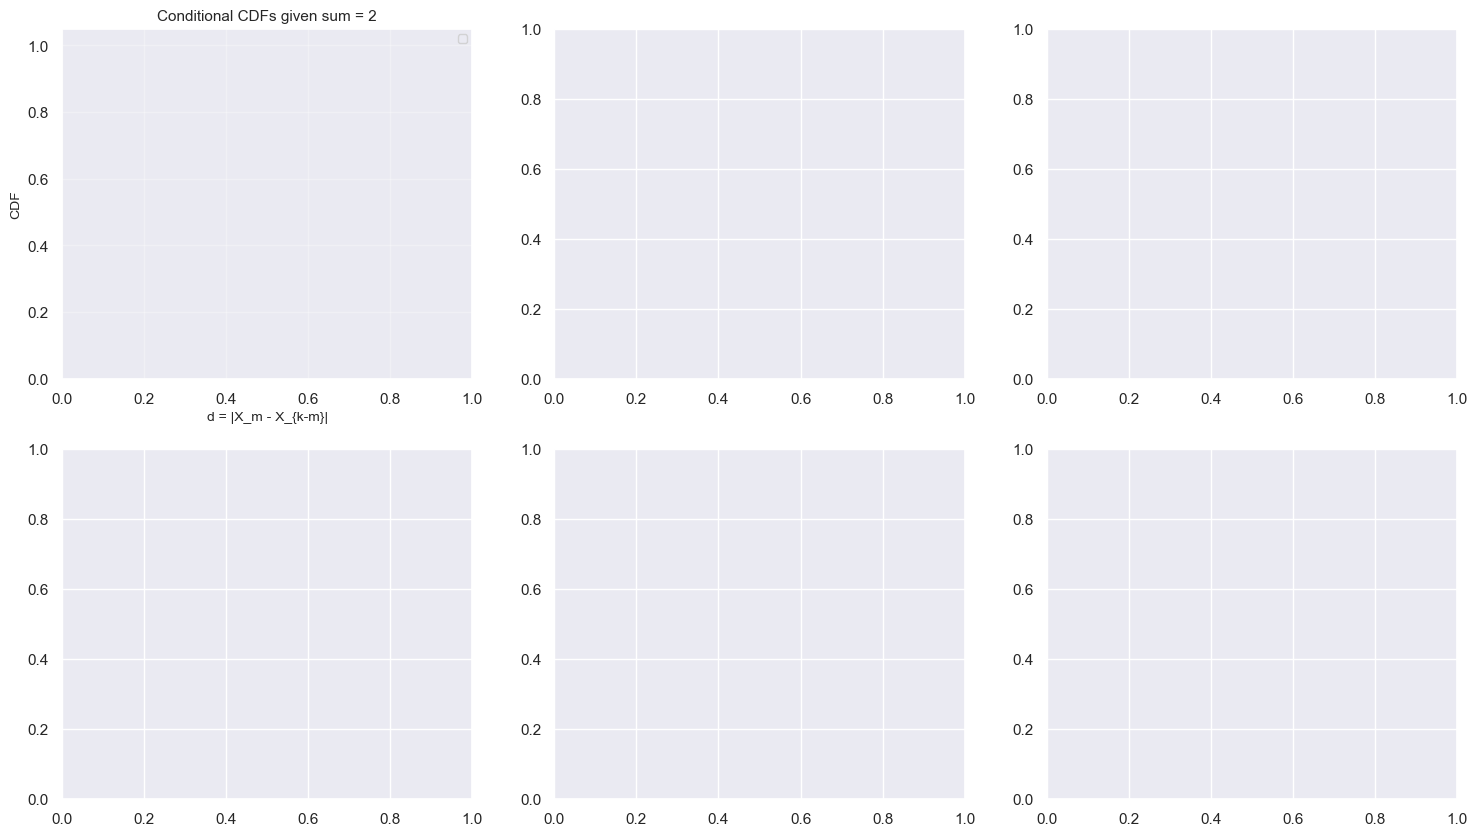

In [33]:
def verify_claim_3(k, T):
    """
    Verify Claim 3: |X_m - X_{k-m}| | {X_m + X_{k-m} = s} is stochastically 
    decreasing in m for 1 <= m <= k/2.
    
    Args:
        k: Total number of leaves
        T: Branch length
        s_values: List of sum values to check. If None, checks all possible sums.
    """
    m_max = k
    
    # Pre-calculate g_ij values
    g_array = np.full((m_max + 1, m_max + 1), 0.0)
    for i in range(1, m_max + 1):
        for j in range(1, i+1):
            g_array[i, j] = g_ij(T, i, j)
    
    # Calculate distributions for all X_i up to k
    z_array = np.zeros((m_max+1, m_max+1))
    x_array = np.zeros((m_max+1, m_max+1))
    
    z_array[1, 1] = 1
    x_array[1, 1] = 1
    
    for i in range(2, m_max+1):
        l = i // 2
        r = (i+1) // 2
        x_array[i, :] = np.convolve(z_array[l, :], z_array[r,:], mode='full')[:m_max+1]
        z_array[i, :] = x_array[i, :] @ g_array
    
    
    s_values = list(range(2, k+1))
    m_values = list(range(1, k // 2 + 1))
    d_values = list(range(k))
        
    print(f'Testing Claim 3 for k={k}, T={T}')
    print(f'Checking m values {m_values}')
    print(f'Checking possible sums s = {s_values}')
    
    
    # Determine conditional distributions 
    # cond_dist[m, d, s] = P(|Xm - X_{k-m}=d| | X_m + X_{k-m} = s)
    # sum_dists[m, s ] = P(X_m + X_{k-m} = s)
    cond_dists = np.zeros((k//2 + 1, k, k + 1))
    sum_dists = np.zeros((k//2 + 1, k + 1))
    
    for m in m_values:
        xm_dist = x_array[m, :]
        other_dist = x_array[k-m, :] 
        
        # Calculate joint prob P(diff = d and sum = s) and marginal prob P(sum=s)
        for x, px in enumerate(xm_dist):
            for y, py in enumerate(other_dist):
                
                d = abs(x-y)
                s = x + y
                prob = px * py
                if prob > 0:
                    cond_dists[m, d, s] += prob
                    sum_dists[m,s] += prob
                         
        # Renormalize to get conditional distributions
        for s in s_values:
            cond_dists[m,d, :] /= sum_dists[m, :] # FIX ME????
        

    # Check stochastic ordering for a few sum values
    test_s_values = s_values[::max(1, len(s_values)//5)][:5]  # Test ~5 values
    
    for s in test_s_values:
        print(f"\nSum s = {s}")
        print("-" * 40)
        violations = []
        
        for i, m1 in enumerate(m_values[:-1]):
            m2 = m_values[i + 1]
            
            if sum_dists[m1, s] < 1e-10 or sum_dists[m2, s] < 1e-10:
                continue
            
            # Compute CDFs
            cdf1 = np.cumsum(cond_dists[m1, :, s])
            cdf2 = np.cumsum(cond_dists[m2, :, s])
            
            # Check if cdf1 >= cdf2 (m1 stochastically dominates m2)
            for d in range(len(cdf1)):
                if cdf1[d] < cdf2[d] - 1e-10:
                    violations.append((m1, m2, d, cdf1[d], cdf2[d]))
        
        if violations:
            print(f"  ✗ Found {len(violations)} violations")
            for v in violations[:3]:
                m1, m2, d, cdf1_d, cdf2_d = v
                print(f"    m={m1} vs m={m2}, d={d}: CDF({m1})={cdf1_d:.4f} < CDF({m2})={cdf2_d:.4f}")
        else:
            print(f"  ✓ Stochastic ordering holds!")
            # Show means
            means = []
            for m in m_values:
                if sum_dists[m, s] > 1e-10:
                    mean = np.sum(np.arange(k) * cond_dists[m, :, s])
                    means.append((m, mean))
            if len(means) >= 2:
                print(f"    Sample means: ", end="")
                for m, mean in means[:3]:
                    print(f"E[|diff| | m={m}] = {mean:.3f}  ", end="")
                print()
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    plot_s_values = s_values[::max(1, len(s_values)//6)][:6]
    
    for idx, s in enumerate(plot_s_values):
        ax = axes[idx]
        
        for m in m_values:
            if sum_dists[m, s] < 1e-10:
                continue
            
            cdf = np.cumsum(cond_dists[m, :, s])
            # Only plot non-zero part
            last_nonzero = np.where(cdf > 1e-10)[0]
            if len(last_nonzero) > 0:
                plot_range = range(last_nonzero[-1] + 2)
                ax.plot(plot_range, cdf[plot_range], '-o', label=f'm={m}', markersize=4)
        
        ax.set_xlabel('d = |X_m - X_{k-m}|', fontsize=10)
        ax.set_ylabel('CDF', fontsize=10)
        ax.set_title(f'Conditional CDFs given sum = {s}', fontsize=11)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])
    
    plt.suptitle(f'Claim 3 verification: k={k}, T={T}\n(Curves should be decreasing in m for stochastic decrease)', 
                 fontsize=13)
    plt.tight_layout()
    plt.show()                 

    
    
# Test
verify_claim_3(k=4, T=1.0)